<a href="https://colab.research.google.com/github/Deni-Alves/MOSFET_model/blob/main/Examples/Design%20Methodologies/RfeedbackLNA_design/LNA_design_with_ACM2_git2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
Set-up environment
---

In [ ]:
#@title Clear Variables
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [ ]:
#@title Import Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt
from sympy import *

-----------------------------------------------------------------------------

# R-FEEDBACK LNA CIRCUIT ANALYSIS

Our case study in this manuscript is the R-feedback LNA
topology shown below

![LNA](https://drive.google.com/uc?export=view&id=1jpxSbJuNGNYTMgza5TBFrfBTYtHEwdse)

Whereas the feedback resistor, $R_F$ is mainly used to synthesize a real part in the input impedance, an L−type matching network composed of $L_G$ and $C'_{GS}$ is added to null the imaginary part while controlling
the input Q factor, $Q_{IN}$.

 The input impedance of the circuit, $Z_{IN}$ is given by:


\begin{align}
    Z_{IN}=L_G s + \left(\frac{1}{(C_{GS}+C_{GS}')s} // Z_P \right)
\end{align}

where $Z_P$ in the input impedance seen between the $M$ gate and its source and due to the resistive feedback which is expressed through its real and imaginary parts as follows:


\begin{equation}
    \Re(Zp)=\frac{1+\left( \frac{f}{f_c}\right)^2}{\frac{1+G_mR_O}{R_O+R_F}+\frac{1}{R_F}\left( \frac{f}{f_c}\right)^2},
    %R_{P}=\frac{(R_O+R_F)^2+(R_FR_OC_L\omega)^2}{(1+G_mR_O)(R_O+R_F)+R_F(R_OC_L\omega)^2},
\end{equation}

and

\begin{equation}
    %=\frac{R_O^2C_L(G_mR_F-1)}{(R_O+R_F)^2+(R_FR_OC_L\omega)^2}
    \Im(Zp)=-\left( 1+\frac{R_F}{R_O}\right)^2 \frac{1+\left( \frac{f}{f_c}\right)^2}{2\pi f C_L (G_mR_F-1)},
\end{equation}

with

\begin{equation}
    R_{O}=\frac{R_Lr_{DS}}{R_L+r_{DS}},
\end{equation}

and

\begin{equation}
    f_c=\frac{R_O+R_F}{2\pi R_OR_FC_L}.
\end{equation}

For an operating frequency, $f=f_0$,  well bellow the cutting frequency, $f_c$ (\ref{Rp}) and (\ref{Cp}) become,

\begin{equation}
    \Re(Zp)=R_{P}=\frac{R_O+R_F}{1+G_mR_O},
\end{equation}

and

\begin{equation}
    \Im(Zp)=-\frac{1}{2 \pi f_0 C_P},
\end{equation}

with,

\begin{equation}
    C_{P}=\frac{R_O^2C_L(G_mR_F-1)}{(R_O+R_F)^2},
\end{equation}


with $G_m$ the transconductance of the MOS.

Defining $Q_P$ as follows:


\begin{equation}
    Q_P=R_P C_T\omega_0,
\end{equation}


with


\begin{equation}
    C_{T}=C_{GS}+C_{GS}'+C_P,
\end{equation}

the matching conditions are,

\begin{equation}
    \Re(Z_{IN})=R_S=\frac{R_P}{(1+Q_P^2)},
\end{equation}

\begin{equation}
    \Im(Z_{IN})=0=L_Gs+\frac{Q_P^2}{C_Ts(1+Q_P)^2},
\end{equation}

with $R_S$ the impedance of the source generator which, for a LNA, corresponds to the antenna impedance.

The total voltage gain can be defined according to the operating frequency and the cutting frequency as,

\begin{equation}
    |G_o|=\left \lvert \frac{V_O}{V_{RF}}\right\rvert = \frac{|G_T|}{\sqrt{\left( 1+ \left( \frac{f_0}{f_c}\right)^2 \right)}},
\end{equation}

where

\begin{equation}
    |G_T|= |G_v|Q_{IN}= \frac{(G_mR_F-1)R_O}{(R_O+R_F)}\sqrt{1+Q_P^2},
\end{equation}

with $Q_{IN}=V_{I}/V_{RF}$ the input Q factor which, for $f_0 ≪ f_c$, can be simplified from (\ref{Re(Zin)}) and (\ref{Rpsimpl}) as,

\begin{equation}
    Q_{IN}=\sqrt{1+Q_P^2}=\sqrt{\frac{R_O+R_F}{R_S(1+G_mR_O)}}.
\end{equation}

As for the gain, the noise factor $F$ and the $IIP_3$ in matched conditions depend on $Q_{IN}$ and can be expressed as,

\begin{equation}
    F=1+\frac{4\left( \frac{R_F}{Q_{IN}^2} + R_S\right)^2}{Q_{IN}^2G_mR_S\left[ \frac{R_F}{Q_{IN}^2} + R_S + \frac{G_mR_SR_FR_L)}{R_F+R_L} \right]^2}
    \left[ \gamma + \frac{1}{G_mR_L} +\frac{\left( 1+\frac{Q_{IN}^2G_mR_SR_F}{R_F+Q_{IN}^2R_S}\right)^2}{G_mR_F} \right],
\end{equation}

\begin{equation}
    V_{IIP3}=\frac{2}{Q_{IN}}\sqrt{\frac{2G_m}{G_{m3}}}.
\end{equation}

---

# ACM2

---


In [ ]:
#@title Model parameters

VT0 = 394e-3
ISL = 2.94
n = 1.16
sigma = 17e-3
zeta = 39e-3

#Transistor Dimensions
W = 1e-6
L = 0.006e-6

#Technologic parameters
phit = 25.8e-3
tox = 3.98e-9
e0 = 8.85e-12
eox = 3.9
Cox = (eox*e0)/tox
epsi = 0.1

##  DC Characteristics

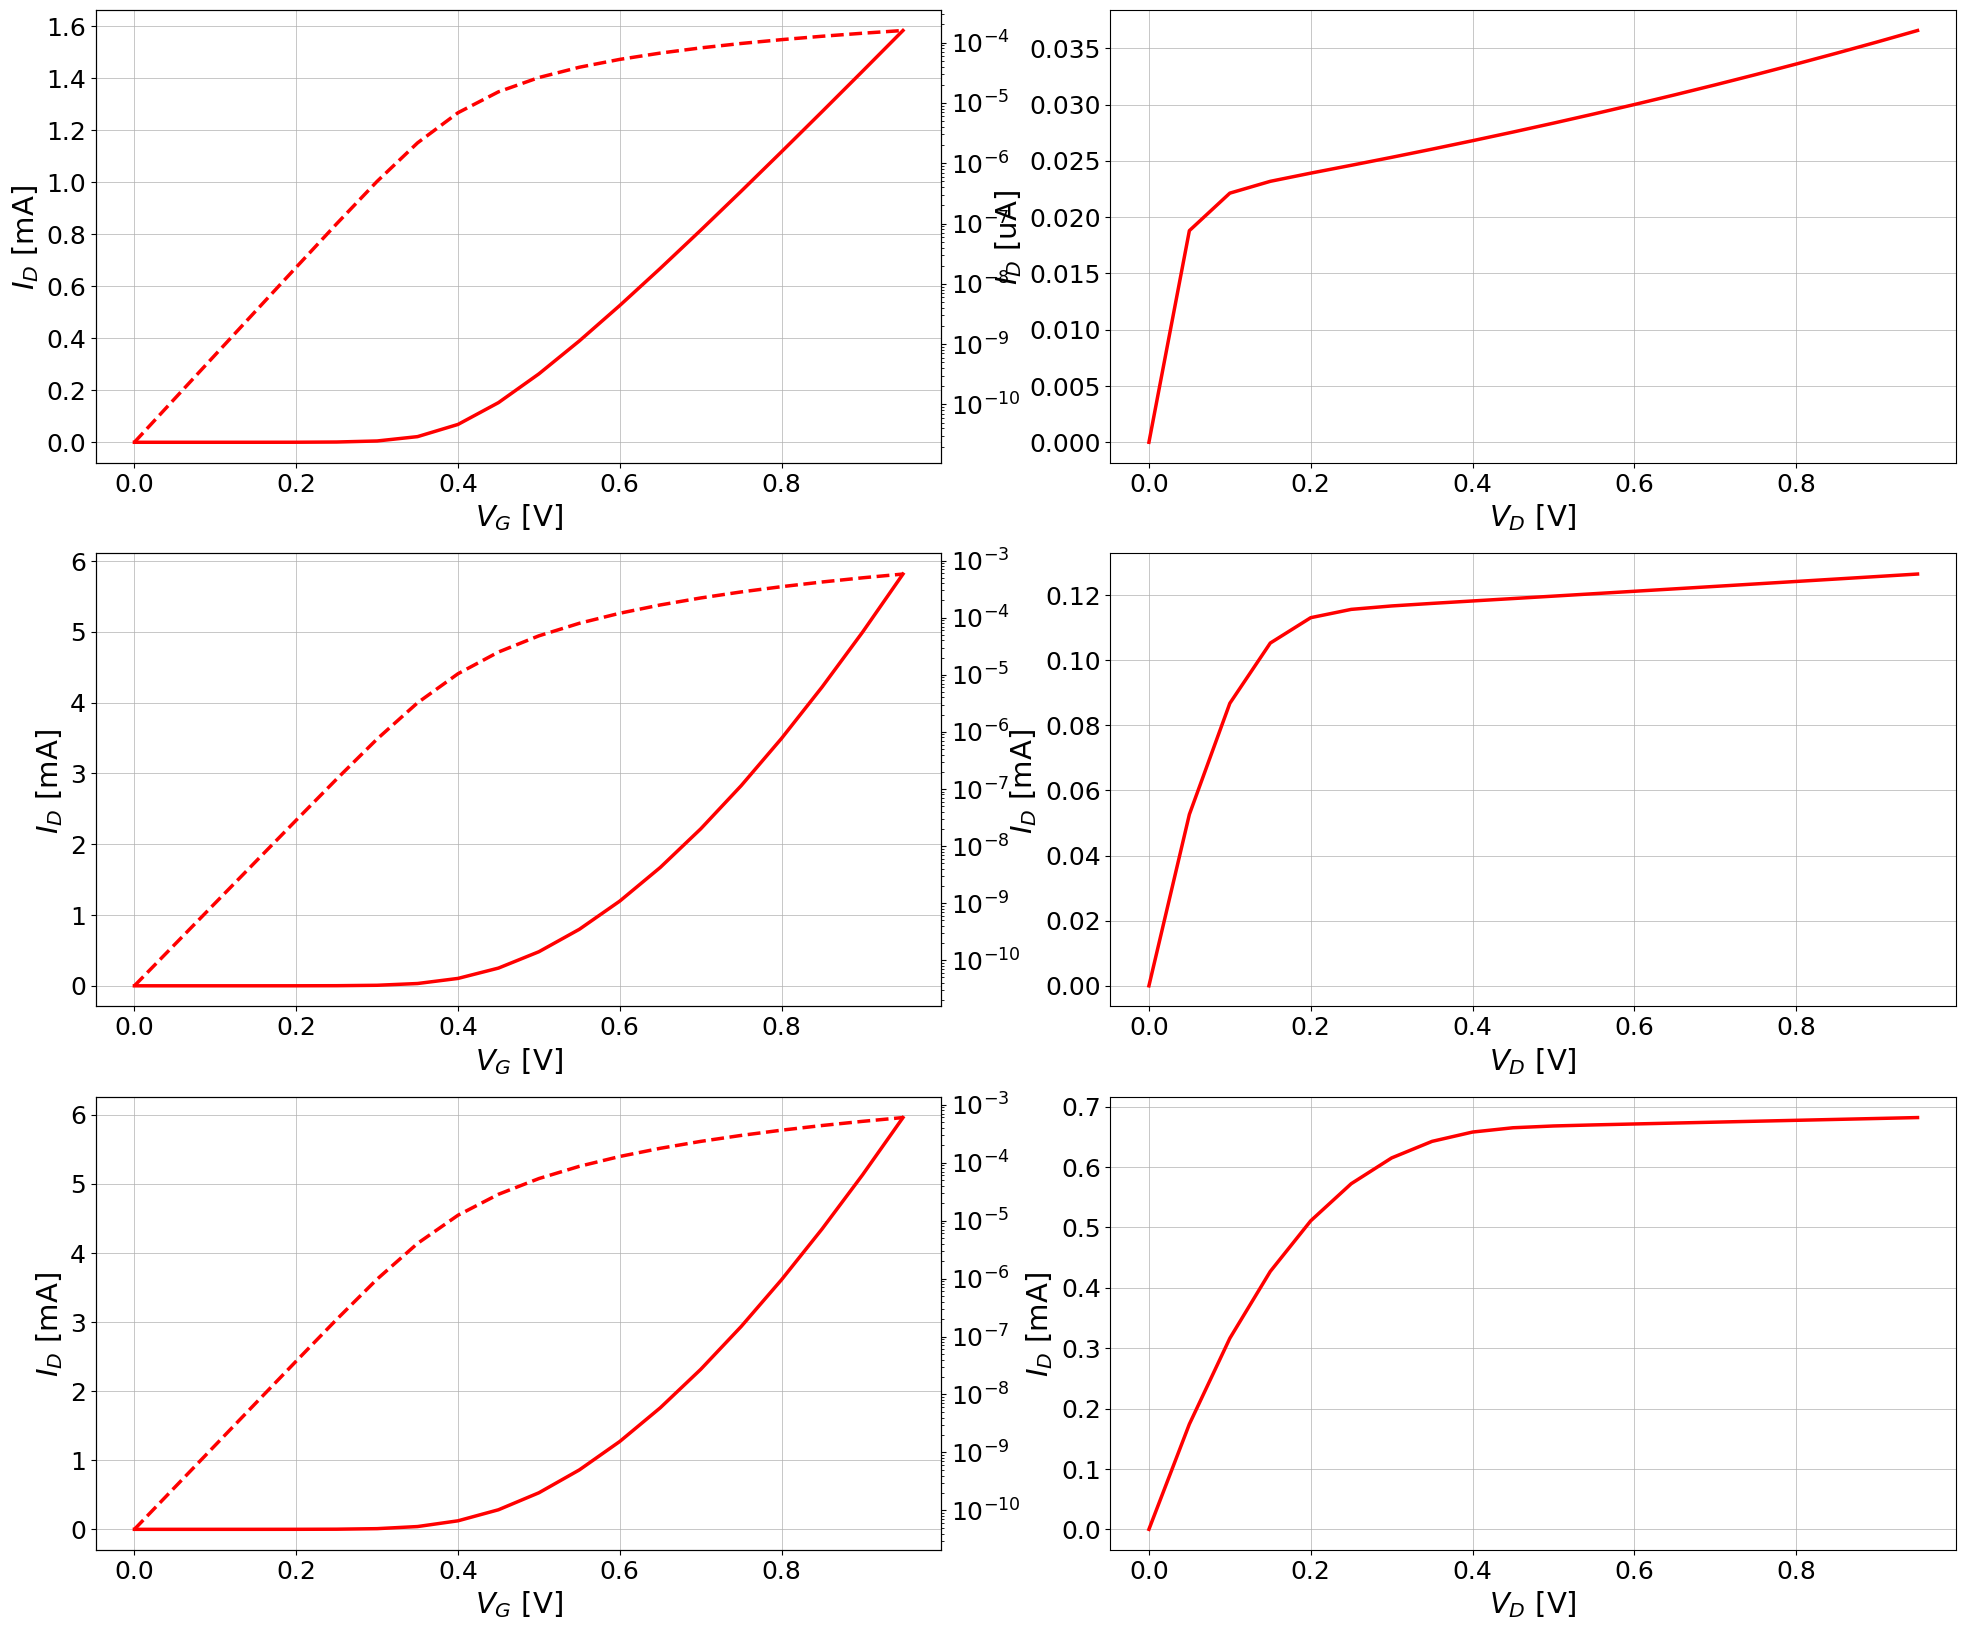

In [ ]:
#@title ID vs VG & ID vs VD

def ACM(VT0, IS, n, sigma, zeta):

  VS_ACM = np.zeros(numVD)
  VDS = VD_ACM - VS_ACM

  #defined intern Variables
  nums = len(VDS)
  numeratorD = 0
  denominatorD = 0
  X = np.zeros(nums)
  Z = 0
  VP = np.zeros(nums)
  WnD = 0
  ZnD = 0
  q1 = np.zeros(nums)
  qsat = np.zeros(nums)
  numd = len(VDS)
  Y = np.zeros(numd)
  q2 = np.zeros(numd)
  qS = np.zeros(numd)
  qD = np.zeros(numd)
  nummeratorED = 0
  denomiatorED = 0
  EnD = 0
  qn = 0

  # Algorithm 443 to solve UCCM
  def algo_443(Z):
    if Z < 0.7385:
        numeratorD = Z + (4.0/3.0)*Z*Z
        denominatorD = 1.0 + (7.0/3.0)*Z + (5.0/6.0)*Z*Z
        WnD = numeratorD / denominatorD
    else:
        numeratorD = np.log(Z)*np.log(Z) + 2.0*np.log(Z) - 3.0
        denominatorD = 7.0*np.log(Z)*np.log(Z) + 58.0*np.log(Z) + 127.0
        WnD = np.log(Z) - 24.0*(numeratorD / denominatorD)

    ZnD = np.log(Z) - WnD - np.log(WnD)
    TermD = ZnD / (1.0 + WnD)
    numeratorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - ZnD
    denominatorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - 2 * ZnD
    EnD = TermD * (numeratorED / denominatorED)
    qn = WnD * (1 + EnD)
    return qn

  for i in range(nums):

    VP[i] = (VG_ACM[i] - VT0 + sigma*(VD_ACM[i]+VS_ACM[i]))/n
  #q1 from algorithm 443 and UCCM
    X[i] = np.exp(((VP[i] -VS_ACM[i])/phit)+1)
    q1[i] = algo_443(X[i])

  #Calculating qdsat
    qsat[i] = q1[i] + 1 + (1/zeta) - np.sqrt(((1+(1/zeta))*(1+(1/zeta)))+((2*q1[i])/zeta))

  #q2 from algorithm 443 and UCCM
    Y[i] = (((q1[i]-qsat[i]))*np.exp(-VDS[i]/(phit))*np.exp(q1[i]-qsat[i]))
    q2[i] = algo_443(Y[i]) +qsat[i]

  #Normalized densities charges for a symmetric model
    qS[i] = q1[i]
    qD[i] = q2[i]

  #####################Calculating Drain Current ID###############################

  id_ACM = ((qD+qS+2)/(1+ np.sqrt((zeta*(qS-qD))*zeta*((qS-qD))+(epsi*epsi))))*(qS - qD)
  ID_ACM = ISL*W*id_ACM
  return ID_ACM


# ID vs VG @ VD
VG_ACM = np.arange(0, 1, 0.05)
numVD = len(VG_ACM)
VD_ACM = (np.zeros(numVD)+0.05)
ID1 = ACM(VT0, ISL, n, sigma, zeta)

VD_ACM = (np.zeros(numVD)+0.5)
ID2 = ACM(VT0, ISL, n, sigma, zeta)

VD_ACM = (np.zeros(numVD)+1)
ID3 = ACM(VT0, ISL, n, sigma, zeta)


################ VD = 50 mV ##########
fig, ax1 = plt.subplots(3,2,figsize=(24, 20))
ax2 = ax1[0,0].twinx()

ax1[0,0].plot(VG_ACM,ID1*(10e3),'r',linewidth=2.5)
ax2.semilogy(VG_ACM,ID1,'r--',linewidth=2.5)
#Labels
ax1[0,0].set_ylabel('$I_D$ [mA] ',fontsize=21)
#ax2.set_ylabel('$g_m/I_D$ ',fontsize=21)
ax1[0,0].set_xlabel('$V_G$ [V]',fontsize=21)
# X and Y axis tick font size
for label in (ax1[0,0].get_xticklabels() + ax1[0,0].get_yticklabels()+ ax2.get_yticklabels()):
	label.set_fontsize(18)
 #grid
ax1[0,0].grid(linewidth=0.5)
#ax1[0,0].legend(loc=2,fontsize=20)

################ VD = 500 mV ##########

ax3 = ax1[1,0].twinx()
ax1[1,0].plot(VG_ACM,ID2*(10e3),'r',linewidth=2.5)
ax3.semilogy(VG_ACM,ID2,'r--',linewidth=2.5)
#Labels
ax1[1,0].set_ylabel('$I_D$ [mA] ',fontsize=21)
#ax2.set_ylabel('$g_m/I_D$ ',fontsize=21)
ax1[1,0].set_xlabel('$V_G$ [V]',fontsize=21)
# X and Y axis tick font size
for label in (ax1[1,0].get_xticklabels() + ax1[1,0].get_yticklabels()+ ax3.get_yticklabels()):
	label.set_fontsize(18)

#grid
ax1[1,0].grid(linewidth=0.5)
#ax1[1,0].legend(loc=2,fontsize=20)


################ VD = 1 V ##########

ax4 = ax1[2,0].twinx()
ax1[2,0].plot(VG_ACM,ID3*(10e3),'r',linewidth=2.5)
ax4.semilogy(VG_ACM,ID3,'r--',linewidth=2.5)

#Labels
ax1[2,0].set_ylabel('$I_D$ [mA] ',fontsize=21)
#ax2.set_ylabel('$g_m/I_D$ ',fontsize=21)
ax1[2,0].set_xlabel('$V_G$ [V]',fontsize=21)
# X and Y axis tick font size
for label in (ax1[2,0].get_xticklabels() + ax1[2,0].get_yticklabels()+ ax4.get_yticklabels()):
	label.set_fontsize(18)

#grid
ax1[2,0].grid(linewidth=0.5)
#ax1[2,0].legend(loc=2,fontsize=20)

#####################################################
# ID vs VD @ VG
VD_ACM = np.arange(0, 1, 0.05)
numVD = len(VD_ACM)
VG_ACM = (np.zeros(numVD)+0.2)

ID4 = ACM(VT0, ISL, n, sigma, zeta)

VG_ACM = (np.zeros(numVD)+0.6)
ID5 = ACM(VT0, ISL, n, sigma, zeta)

VG_ACM = (np.zeros(numVD)+1)
ID6 = ACM(VT0, ISL, n, sigma, zeta)


################ VG = 200 mV ##########

ax1[0,1].plot(VD_ACM,ID4*(10**6),'r',linewidth=2.5)
#Labels
ax1[0,1].set_ylabel('$I_D$ [uA] ',fontsize=21)
#ax2.set_ylabel('$g_m/I_D$ ',fontsize=21)
ax1[0,1].set_xlabel('$V_D$ [V]',fontsize=21)
# X and Y axis tick font size
for label in (ax1[0,1].get_xticklabels() + ax1[0,1].get_yticklabels()):
	label.set_fontsize(18)
#grid
ax1[0,1].grid(linewidth=0.5)
#ax1[0,1].legend(loc=2,fontsize=20)

################ VG = 600 mV ##########

ax1[1,1].plot(VD_ACM,ID5*(10**3),'r',linewidth=2.5)
#Labels
ax1[1,1].set_ylabel('$I_D$ [mA] ',fontsize=21)
#ax2.set_ylabel('$g_m/I_D$ ',fontsize=21)
ax1[1,1].set_xlabel('$V_D$ [V]',fontsize=21)
# X and Y axis tick font size
for label in (ax1[1,1].get_xticklabels() + ax1[1,1].get_yticklabels()):
	label.set_fontsize(18)
#grid
ax1[1,1].grid(linewidth=0.5)
#ax1[1,1].legend(loc=2,fontsize=20)

################ VG = 1 V ##########

ax1[2,1].plot(VD_ACM,ID6*(10**3),'r',linewidth=2.5)
#Labels
ax1[2,1].set_ylabel('$I_D$ [mA] ',fontsize=21)
#ax2.set_ylabel('$g_m/I_D$ ',fontsize=21)
ax1[2,1].set_xlabel('$V_D$ [V]',fontsize=21)
# X and Y axis tick font size
for label in (ax1[2,1].get_xticklabels() + ax1[2,1].get_yticklabels()):
	label.set_fontsize(18)
#grid
ax1[2,1].grid(linewidth=0.5)
#ax1[2,1].legend(loc=2,fontsize=20)

--------------------------------------------------------------------------------

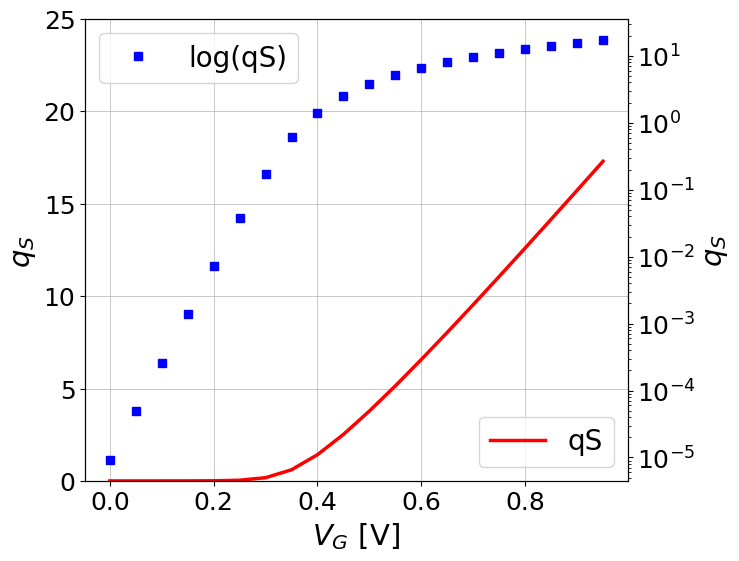

In [ ]:
#@title qS vs VG @ VD

# Simulation input voltages
VG_ACM = np.arange(0, 1, 0.05)
numVD = len(VG_ACM)
VD_ACM= (np.zeros(numVD)+1)
VS_ACM = np.zeros(numVD)
VDS = VD_ACM - VS_ACM
VSD = -VDS

#defined intern Variables
nums = len(VDS)
numeratorD = 0
denominatorD = 0
X = np.zeros(nums)
Z = 0
VP = np.zeros(nums)
WnD = 0
ZnD = 0
q1 = np.zeros(nums)
qsat = np.zeros(nums)
numd = len(VDS)
Y = np.zeros(numd)
q2 = np.zeros(numd)
qS = np.zeros(numd)
qD = np.zeros(numd)
nummeratorED = 0
denomiatorED = 0
EnD = 0
qn = 0

# Algorithm 443 to solve UCCM
def algo_443(Z):
  if Z < 0.7385:
      numeratorD = Z + (4.0/3.0)*Z*Z
      denominatorD = 1.0 + (7.0/3.0)*Z + (5.0/6.0)*Z*Z
      WnD = numeratorD / denominatorD
  else:
      numeratorD = np.log(Z)*np.log(Z) + 2.0*np.log(Z) - 3.0
      denominatorD = 7.0*np.log(Z)*np.log(Z) + 58.0*np.log(Z) + 127.0
      WnD = np.log(Z) - 24.0*(numeratorD / denominatorD)

  ZnD = np.log(Z) - WnD - np.log(WnD)
  TermD = ZnD / (1.0 + WnD)
  numeratorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - ZnD
  denominatorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - 2 * ZnD
  EnD = TermD * (numeratorED / denominatorED)
  qn = WnD * (1 + EnD)
  return qn

for i in range(nums):

  VP[i] = (VG_ACM[i] - VT0 + sigma*(VD_ACM[i]+VS_ACM[i]))/n
#q1 from algorithm 443 and UCCM
  X[i] = np.exp(((VP[i] -VS_ACM[i])/phit)+1)
  q1[i] = algo_443(X[i])

#Calculating qdsat
  qsat[i] = q1[i] + 1 + (1/zeta) - np.sqrt(((1+(1/zeta))*(1+(1/zeta)))+((2*q1[i])/zeta))

#q2 from algorithm 443 and UCCM
  Y[i] = (((q1[i]-qsat[i]))*np.exp(-VDS[i]/(phit))*np.exp(q1[i]-qsat[i]))
  q2[i] = algo_443(Y[i]) +qsat[i]

#Normalized densities charges for a symmetric model
  qS = q1
  qD = q2
#####################Calculating Drain Current ID###############################

id_ACM = ((qD+qS+2)/(1+ np.sqrt((zeta*(qS-qD))*zeta*((qS-qD))+(epsi*epsi))))*(qS - qD)
ID_ACM = ISL*W*id_ACM


fig, ax1 = plt.subplots(figsize=(7, 6))
ax2 = ax1.twinx()


ax1.plot(VG_ACM,qS,'r',linewidth=2.5, label='qS')
ax2.semilogy(VG_ACM,qS,'bs',linewidth=2.5, label='log(qS)')



#ax1.set_xlim(-0.5, 1.35)
ax1.set_ylim(0, 25)
#Labels
ax1.set_ylabel('$q_S$ ',fontsize=21)
ax2.set_ylabel('$q_S$',fontsize=21)
ax1.set_xlabel('$V_G$ [V]',fontsize=21)


# X and Y axis tick font size
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()+ ax2.get_yticklabels()):
		label.set_fontsize(18)

#grid
ax1.grid(linewidth=0.5)
ax1.legend(loc=4,fontsize=20)
ax2.legend(loc=2,fontsize=20)


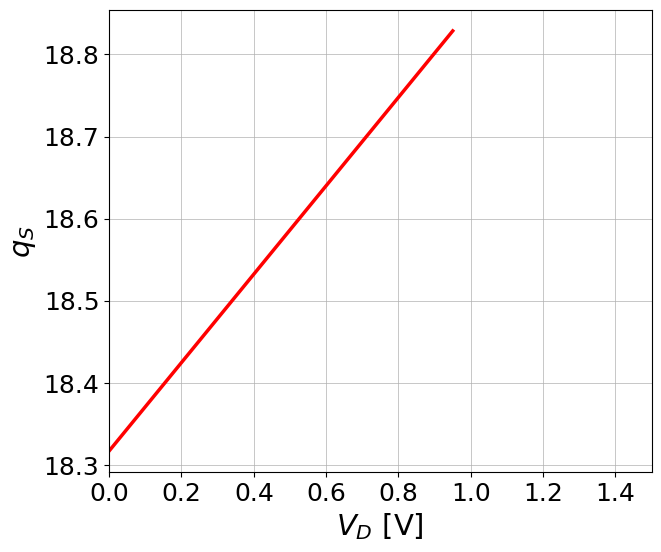

In [ ]:
#@title qS vs VD @ VG

# Simulation input voltages
VD_ACM = np.arange(0, 1, 0.05)
numVD = len(VD_ACM)
VG_ACM= (np.zeros(numVD)+1)
VS_ACM = np.zeros(numVD)
VDS = VD_ACM - VS_ACM
VSD = -VDS

#defined intern Variables
nums = len(VDS)
numeratorD = 0
denominatorD = 0
X = np.zeros(nums)
Z = 0
VP = np.zeros(nums)
WnD = 0
ZnD = 0
q1 = np.zeros(nums)
qsat = np.zeros(nums)
numd = len(VDS)
Y = np.zeros(numd)
q2 = np.zeros(numd)
qS = np.zeros(numd)
qD = np.zeros(numd)
nummeratorED = 0
denomiatorED = 0
EnD = 0
qn = 0

# Algorithm 443 to solve UCCM
def algo_443(Z):
  if Z < 0.7385:
      numeratorD = Z + (4.0/3.0)*Z*Z
      denominatorD = 1.0 + (7.0/3.0)*Z + (5.0/6.0)*Z*Z
      WnD = numeratorD / denominatorD
  else:
      numeratorD = np.log(Z)*np.log(Z) + 2.0*np.log(Z) - 3.0
      denominatorD = 7.0*np.log(Z)*np.log(Z) + 58.0*np.log(Z) + 127.0
      WnD = np.log(Z) - 24.0*(numeratorD / denominatorD)

  ZnD = np.log(Z) - WnD - np.log(WnD)
  TermD = ZnD / (1.0 + WnD)
  numeratorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - ZnD
  denominatorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - 2 * ZnD
  EnD = TermD * (numeratorED / denominatorED)
  qn = WnD * (1 + EnD)
  return qn

for i in range(nums):

  VP[i] = (VG_ACM[i] - VT0 + sigma*(VD_ACM[i]+VS_ACM[i]))/n
#q1 from algorithm 443 and UCCM
  X[i] = np.exp(((VP[i] -VS_ACM[i])/phit)+1)
  q1[i] = algo_443(X[i])

#Calculating qdsat
  qsat[i] = q1[i] + 1 + (1/zeta) - np.sqrt(((1+(1/zeta))*(1+(1/zeta)))+((2*q1[i])/zeta))

#q2 from algorithm 443 and UCCM
  Y[i] = (((q1[i]-qsat[i]))*np.exp(-VDS[i]/(phit))*np.exp(q1[i]-qsat[i]))
  q2[i] = algo_443(Y[i]) +qsat[i]

#Normalized densities charges for a symmetric model
  qS = q1
  qD = q2

#####################Calculating Drain Current ID###############################

id_ACM = ((qD+qS+2)/(1+ np.sqrt((zeta*(qS-qD))*zeta*((qS-qD))+(epsi*epsi))))*(qS - qD)
ID_ACM = ISL*W*id_ACM

############################Transconductances###################################

fig, ax1 = plt.subplots(figsize=(7, 6))

ax1.plot(VD_ACM,qS,'r',linewidth=2.5)



#Labels
ax1.set_ylabel('$q_S$ ',fontsize=21)
ax1.set_xlabel('$V_D$ [V]',fontsize=21)
ax1.set_xlim(0, 1.5)

# X and Y axis tick font size
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()):
		label.set_fontsize(18)

#grid
ax1.grid(linewidth=0.5)
#ax1.legend(loc=4,fontsize=20)



##Transconductances in saturation

Transconductances, defined as the derivatives of the current with respect to the control voltages, are crucial for reliable and efficient convergence of the DC analysis.

\begin{align}
g_{msat} = \frac{\partial I_{Dsat}}{\partial V_G} ;  g_{msat3} = - \frac{\partial^3 I_{Dsat}}{\partial V_G^3} ;  g_{dsat} = \frac{\partial I_D}{\partial V_D} ;
\end{align}

In terms of $q_s$:

\begin{align}
g_{msat} = \frac{2 I_S}{n \phi_t} \frac{q_s}{1+\zeta(q_s +1) }
\end{align}


\begin{align}
g_{msat3} = \frac{16 I_S}{(n \phi_t)^3} \frac{q_s}{(q_s +1)^3} \frac{2 - 2 \zeta q_s -3 \zeta q_s^2}{(\zeta q_s +2)^4}
\end{align}


\begin{align}
g_{dsat} = \frac{\sigma}{n} \frac{2 I_S}{\phi_t} \frac{q_s}{1+\zeta(q_s +1) }
\end{align}

But also can be expressed in terms of $i_{dsat}$ trough the change of variable in $q_s = \sqrt{1+i_{dsat}} - 1$

\begin{align}
g_{msat} = \frac{2 I_S}{n \phi_t} \frac{\sqrt{1+i_{dsat}}-1}{1+\zeta \sqrt{i_{dsat}}}
\end{align}

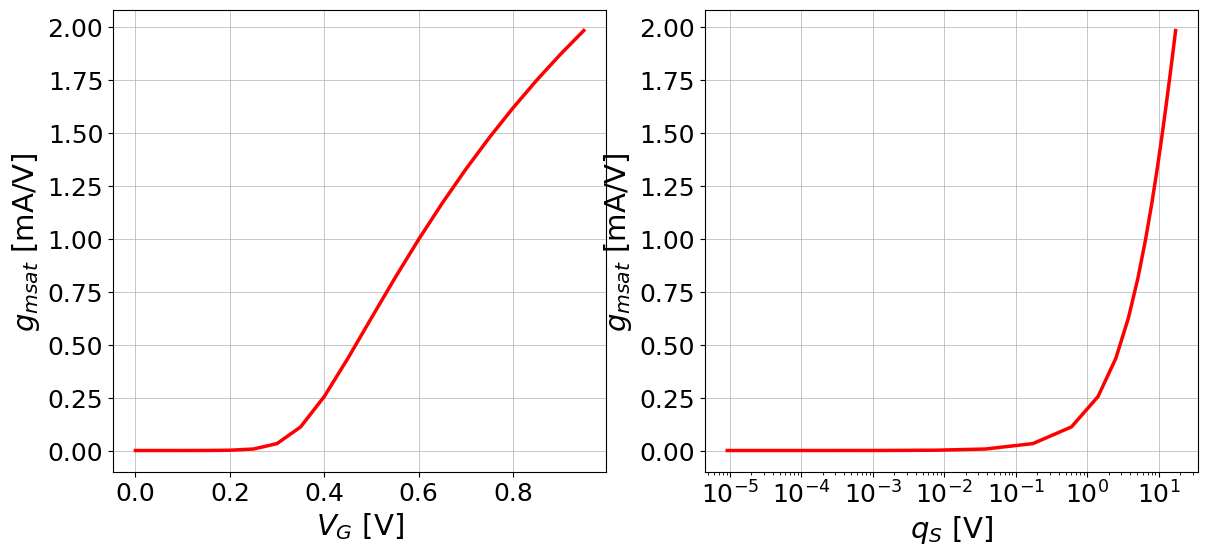

In [ ]:
#@title gmsat vs VG & qS @ VD
# Simulation input voltages
VG_ACM = np.arange(0, 1, 0.05)
numVD = len(VG_ACM)
VD_ACM= (np.zeros(numVD)+1)
VS_ACM = np.zeros(numVD)
VDS = VD_ACM - VS_ACM
VSD = -VDS

#defined intern Variables
nums = len(VDS)
numeratorD = 0
denominatorD = 0
X = np.zeros(nums)
Z = 0
VP = np.zeros(nums)
WnD = 0
ZnD = 0
q1 = np.zeros(nums)
qsat = np.zeros(nums)
numd = len(VDS)
Y = np.zeros(numd)
q2 = np.zeros(numd)
qS = np.zeros(numd)
qD = np.zeros(numd)
nummeratorED = 0
denomiatorED = 0
EnD = 0
qn = 0

# Algorithm 443 to solve UCCM
def algo_443(Z):
  if Z < 0.7385:
      numeratorD = Z + (4.0/3.0)*Z*Z
      denominatorD = 1.0 + (7.0/3.0)*Z + (5.0/6.0)*Z*Z
      WnD = numeratorD / denominatorD
  else:
      numeratorD = np.log(Z)*np.log(Z) + 2.0*np.log(Z) - 3.0
      denominatorD = 7.0*np.log(Z)*np.log(Z) + 58.0*np.log(Z) + 127.0
      WnD = np.log(Z) - 24.0*(numeratorD / denominatorD)

  ZnD = np.log(Z) - WnD - np.log(WnD)
  TermD = ZnD / (1.0 + WnD)
  numeratorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - ZnD
  denominatorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - 2 * ZnD
  EnD = TermD * (numeratorED / denominatorED)
  qn = WnD * (1 + EnD)
  return qn

for i in range(nums):

  VP[i] = (VG_ACM[i] - VT0 + sigma*(VD_ACM[i]+VS_ACM[i]))/n
#q1 from algorithm 443 and UCCM
  X[i] = np.exp(((VP[i] -VS_ACM[i])/phit)+1)
  q1[i] = algo_443(X[i])

#Calculating qdsat
  qsat[i] = q1[i] + 1 + (1/zeta) - np.sqrt(((1+(1/zeta))*(1+(1/zeta)))+((2*q1[i])/zeta))

#q2 from algorithm 443 and UCCM
  Y[i] = (((q1[i]-qsat[i]))*np.exp(-VDS[i]/(phit))*np.exp(q1[i]-qsat[i]))
  q2[i] = algo_443(Y[i]) +qsat[i]

#Normalized densities charges for a symmetric model
  qS = q1
  qD = q2
#####################Calculating Drain Current ID###############################

id_ACM = ((qD+qS+2)/(1+ np.sqrt((zeta*(qS-qD))*zeta*((qS-qD))+(epsi*epsi))))*(qS - qD)
ID_ACM = ISL+W*id_ACM


###########################Calculating Transconductance#########################

#gmsat= 2*(IS/(n*phit))*((np.sqrt(1+id_ACM)-1)/(1+zeta*np.sqrt(1+id_ACM)))
gmsat= 2*(ISL*W/(n*phit))*((qS)/(1+zeta*(1+qS)))

#################Fig plot#########################
fig, ax1 = plt.subplots(1,2,figsize=(14, 6))

ax1[0].plot(VG_ACM,gmsat*(10**3),'r',linewidth=2.5)

#Labels
ax1[0].set_ylabel('$g_{msat}$ [mA/V] ',fontsize=21)
ax1[0].set_xlabel('$V_G$ [V]',fontsize=21)


# X and Y axis tick font size
for label in (ax1[0].get_xticklabels() + ax1[0].get_yticklabels()):
		label.set_fontsize(18)

#grid
ax1[0].grid(linewidth=0.5)
#ax1[0].legend(loc=4,fontsize=20)


ax1[1].semilogx(qS,gmsat*(10**3),'r',linewidth=2.5)

#Labels
ax1[1].set_ylabel('$g_{msat}$ [mA/V] ',fontsize=21)
ax1[1].set_xlabel('$q_S$ [V]',fontsize=21)


# X and Y axis tick font size
for label in (ax1[1].get_xticklabels() + ax1[1].get_yticklabels()):
		label.set_fontsize(18)

#grid
ax1[1].grid(linewidth=0.5)
#ax1[1].legend(loc=4,fontsize=20)

(1e-05, 20.0)

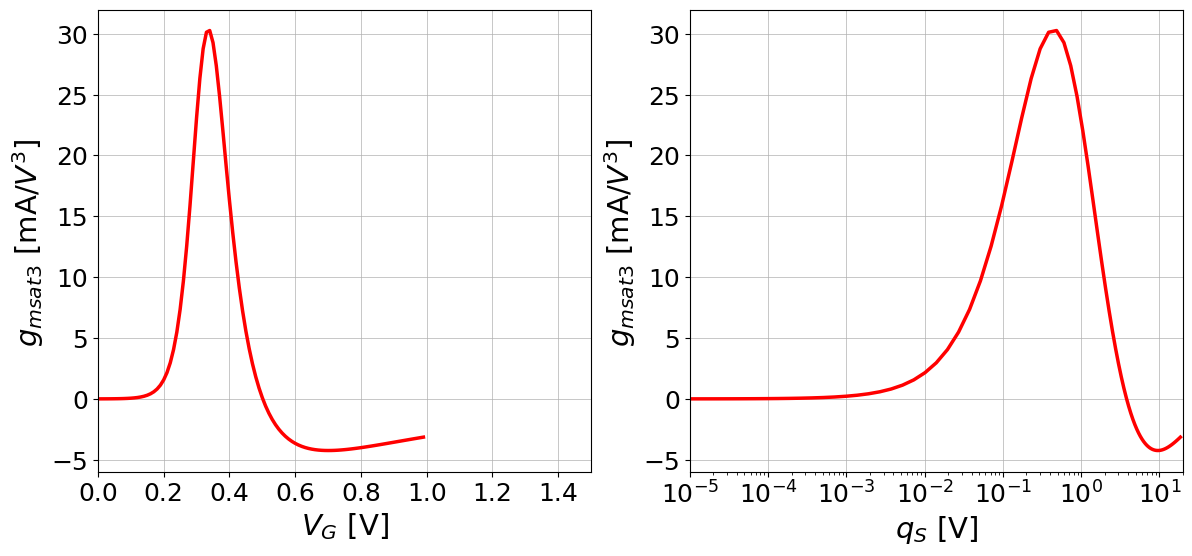

In [ ]:
#@title gmsat3 vs VG & qS @ VD
# Simulation input voltages
VG_ACM = np.arange(0, 1, 0.01)
numVD = len(VG_ACM)
VD_ACM= (np.zeros(numVD)+1)
VS_ACM = np.zeros(numVD)
VDS = VD_ACM - VS_ACM
VSD = -VDS

#defined intern Variables
nums = len(VDS)
numeratorD = 0
denominatorD = 0
X = np.zeros(nums)
Z = 0
VP = np.zeros(nums)
WnD = 0
ZnD = 0
q1 = np.zeros(nums)
qsat = np.zeros(nums)
numd = len(VDS)
Y = np.zeros(numd)
q2 = np.zeros(numd)
qS = np.zeros(numd)
qD = np.zeros(numd)
nummeratorED = 0
denomiatorED = 0
EnD = 0
qn = 0

# Algorithm 443 to solve UCCM
def algo_443(Z):
  if Z < 0.7385:
      numeratorD = Z + (4.0/3.0)*Z*Z
      denominatorD = 1.0 + (7.0/3.0)*Z + (5.0/6.0)*Z*Z
      WnD = numeratorD / denominatorD
  else:
      numeratorD = np.log(Z)*np.log(Z) + 2.0*np.log(Z) - 3.0
      denominatorD = 7.0*np.log(Z)*np.log(Z) + 58.0*np.log(Z) + 127.0
      WnD = np.log(Z) - 24.0*(numeratorD / denominatorD)

  ZnD = np.log(Z) - WnD - np.log(WnD)
  TermD = ZnD / (1.0 + WnD)
  numeratorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - ZnD
  denominatorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - 2 * ZnD
  EnD = TermD * (numeratorED / denominatorED)
  qn = WnD * (1 + EnD)
  return qn

for i in range(nums):

  VP[i] = (VG_ACM[i] - VT0 + sigma*(VD_ACM[i]+VS_ACM[i]))/n
#q1 from algorithm 443 and UCCM
  X[i] = np.exp(((VP[i] -VS_ACM[i])/phit)+1)
  q1[i] = algo_443(X[i])

#Calculating qdsat
  qsat[i] = q1[i] + 1 + (1/zeta) - np.sqrt(((1+(1/zeta))*(1+(1/zeta)))+((2*q1[i])/zeta))

#q2 from algorithm 443 and UCCM
  Y[i] = (((q1[i]-qsat[i]))*np.exp(-VDS[i]/(phit))*np.exp(q1[i]-qsat[i]))
  q2[i] = algo_443(Y[i]) +qsat[i]

#Normalized densities charges for a symmetric model
  qS = q1
  qD = q2

#####################Calculating Drain Current ID###############################

id_ACM = ((qD+qS+2)/(1+ np.sqrt((zeta*(qS-qD))*zeta*((qS-qD))+(epsi*epsi))))*(qS - qD)
ID_ACM = ISL*W*id_ACM

#qS = np.sqrt(1+id_ACM) - 1
###########################Calculating Transconductance#########################

#gmsat3= 16*(IS/(n*phit)**3)*((qS)/((qS+1)*(qS+1)*(qS+1)))*((2-(2*zeta*qS)-(3*zeta*qS**2))/((qS+1)*(qS+1)*(qS+1)*(qS+1)))
#gmsat3= 16*(IS/((n*phit)*(n*phit)*(n*phit)))*((np.sqrt(1+id_ACM) - 1)/((np.sqrt(1+id_ACM))*(np.sqrt(1+id_ACM))*(np.sqrt(1+id_ACM))))*((2-(2*zeta*(np.sqrt(1+id_ACM) - 1))-(3*zeta*(np.sqrt(1+id_ACM) - 1)*(np.sqrt(1+id_ACM) - 1)))/((np.sqrt(1+id_ACM))*(np.sqrt(1+id_ACM))*(np.sqrt(1+id_ACM))*(np.sqrt(1+id_ACM))))
gmsat3_frac1 = (16*ISL*W)/((n*phit)**3)
gmsat3_frac2 = qS/((qS+1)**3)
gmsat3_frac3 = (2-(2*zeta*qS)-(3*zeta*(qS**2)))/((zeta*qS+2)**4)
gmsat3 = gmsat3_frac1*gmsat3_frac2*gmsat3_frac3

#gmsat1 = np.gradient(ID_ACM,VG_ACM)
#gmsat2 = np.gradient(gmsat1,VG_ACM)
#gmsat3 = np.gradient(gmsat2,VG_ACM)
#################Fig plot#########################
fig, ax1 = plt.subplots(1,2,figsize=(14, 6))

ax1[0].plot(VG_ACM,gmsat3*(10**3),'r',linewidth=2.5)

#Labels
ax1[0].set_ylabel('$g_{msat3}$ [mA/$V^3$] ',fontsize=21)
ax1[0].set_xlabel('$V_G$ [V]',fontsize=21)


# X and Y axis tick font size
for label in (ax1[0].get_xticklabels() + ax1[0].get_yticklabels()):
		label.set_fontsize(18)

#grid
ax1[0].grid(linewidth=0.5)
#ax1[0].legend(loc=4,fontsize=20)
ax1[0].set_xlim(0, 1.5)

ax1[1].semilogx(qS,gmsat3*(10**3),'r',linewidth=2.5)

#Labels
ax1[1].set_ylabel('$g_{msat3}$ [mA/$V^3$] ',fontsize=21)
ax1[1].set_xlabel('$q_S$ [V]',fontsize=21)


# X and Y axis tick font size
for label in (ax1[1].get_xticklabels() + ax1[1].get_yticklabels()):
		label.set_fontsize(18)

#grid
ax1[1].grid(linewidth=0.5)
#ax1[1].legend(loc=4,fontsize=20)
ax1[1].set_xlim(1e-5, 2e1)

In [ ]:
#@title  gds vs VD & qS @ VG = 0.5 V

# Simulation input voltages
VD_ACM = np.arange(0.4, 1.5, 0.05)
numVD = len(VD_ACM)
VG_ACM= (np.zeros(numVD)+0.5)
VS_ACM = np.zeros(numVD)
VDS = VD_ACM - VS_ACM
VSD = -VDS

#defined intern Variables
nums = len(VDS)
numeratorD = 0
denominatorD = 0
X = np.zeros(nums)
Z = 0
VP = np.zeros(nums)
WnD = 0
ZnD = 0
q1 = np.zeros(nums)
qsat = np.zeros(nums)
numd = len(VDS)
Y = np.zeros(numd)
q2 = np.zeros(numd)
qS = np.zeros(numd)
qD = np.zeros(numd)
nummeratorED = 0
denomiatorED = 0
EnD = 0
qn = 0

# Algorithm 443 to solve UCCM
def algo_443(Z):
  if Z < 0.7385:
      numeratorD = Z + (4.0/3.0)*Z*Z
      denominatorD = 1.0 + (7.0/3.0)*Z + (5.0/6.0)*Z*Z
      WnD = numeratorD / denominatorD
  else:
      numeratorD = np.log(Z)*np.log(Z) + 2.0*np.log(Z) - 3.0
      denominatorD = 7.0*np.log(Z)*np.log(Z) + 58.0*np.log(Z) + 127.0
      WnD = np.log(Z) - 24.0*(numeratorD / denominatorD)

  ZnD = np.log(Z) - WnD - np.log(WnD)
  TermD = ZnD / (1.0 + WnD)
  numeratorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - ZnD
  denominatorED = 2.0 * (1.0 + WnD) * (1.0 + WnD + (2.0/3.0) * ZnD) - 2 * ZnD
  EnD = TermD * (numeratorED / denominatorED)
  qn = WnD * (1 + EnD)
  return qn

for i in range(nums):

  VP[i] = (VG_ACM[i] - VT0 + sigma*(VD_ACM[i]+VS_ACM[i]))/n
#q1 from algorithm 443 and UCCM
  X[i] = np.exp(((VP[i] -VS_ACM[i])/phit)+1)
  q1[i] = algo_443(X[i])

#Calculating qdsat
  qsat[i] = q1[i] + 1 + (1/zeta) - np.sqrt(((1+(1/zeta))*(1+(1/zeta)))+((2*q1[i])/zeta))

#q2 from algorithm 443 and UCCM
  Y[i] = (((q1[i]-qsat[i]))*np.exp(-VDS[i]/(phit))*np.exp(q1[i]-qsat[i]))
  q2[i] = algo_443(Y[i]) +qsat[i]

#Normalized densities charges for a symmetric model
  qS = q1
  qD = q2

#####################Calculating Drain Current ID###############################

id_ACM = ((qD+qS+2)/(1+ np.sqrt((zeta*(qS-qD))*zeta*((qS-qD))+(epsi*epsi))))*(qS - qD)
ID_ACM = ISL*W*id_ACM

###########################Calculating Transconductance#########################

#gdsat_ACM= 2*sigma*(IS/(n*phit))*((np.sqrt(1+id_ACM)-1)/(1+zeta*np.sqrt(1+id_ACM)))
gdsat= 2*sigma*(ISL*W/(n*phit))*((qS)/(1+zeta*(1+qS)))


###############################Fig plots#########################################
fig, ax1 = plt.subplots(1,2,figsize=(14, 6))

#####Fig 1######
ax1[0].plot(VD_ACM,gdsat*(10**6),'r',linewidth=2.5,)
#Labels
ax1[0].set_ylabel('$g_d$ [$\mu $A/V] ',fontsize=21)
ax1[0].set_xlabel('$V_D$ [V]',fontsize=21)


# X and Y axis tick font size
for label in (ax1[0].get_xticklabels() + ax1[0].get_yticklabels()):
		label.set_fontsize(18)

#grid
ax1[0].grid(linewidth=0.5)
#ax1[0].legend(loc=4,fontsize=20)

#####Fig 2######
ax1[1].plot(qS,gdsat*(10**6),'r',linewidth=2.5,)
#Labels
ax1[1].set_ylabel('$g_d$ [$\mu $A/V] ',fontsize=21)
ax1[1].set_xlabel('$q_S$',fontsize=21)


# X and Y axis tick font size
for label in (ax1[1].get_xticklabels() + ax1[1].get_yticklabels()):
		label.set_fontsize(18)

#grid
ax1[1].grid(linewidth=0.5)
#ax1[1].legend(loc=4,fontsize=20)

<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:101: SyntaxWarning: invalid escape sequence '\m'
<>:86: SyntaxWarning: invalid escape sequence '\m'
<>:101: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_32947/3312838711.py:86: SyntaxWarning: invalid escape sequence '\m'
  ax1[0].set_ylabel('$g_d$ [$\mu $A/V] ',fontsize=21)
/tmp/ipykernel_32947/3312838711.py:101: SyntaxWarning: invalid escape sequence '\m'
  ax1[1].set_ylabel('$g_d$ [$\mu $A/V] ',fontsize=21)


TypeError: unsupported operand type(s) for /: 'int' and 'FunctionClass'

---

# LNA Design Space with ACM2

---

In [ ]:
#@title  Input Variables - LNA

# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

########## Input Variables - LNA ####################
fc = 6e9
N = 4
cL = 200e-15
VDD = 1  # core supply voltage of the technology in V
Rs = 50  # ohms <-- Series resistance
L = 0.06e-6  # transistor length
fo = fc / N
phit = 25.83e-3  # Thermal voltage

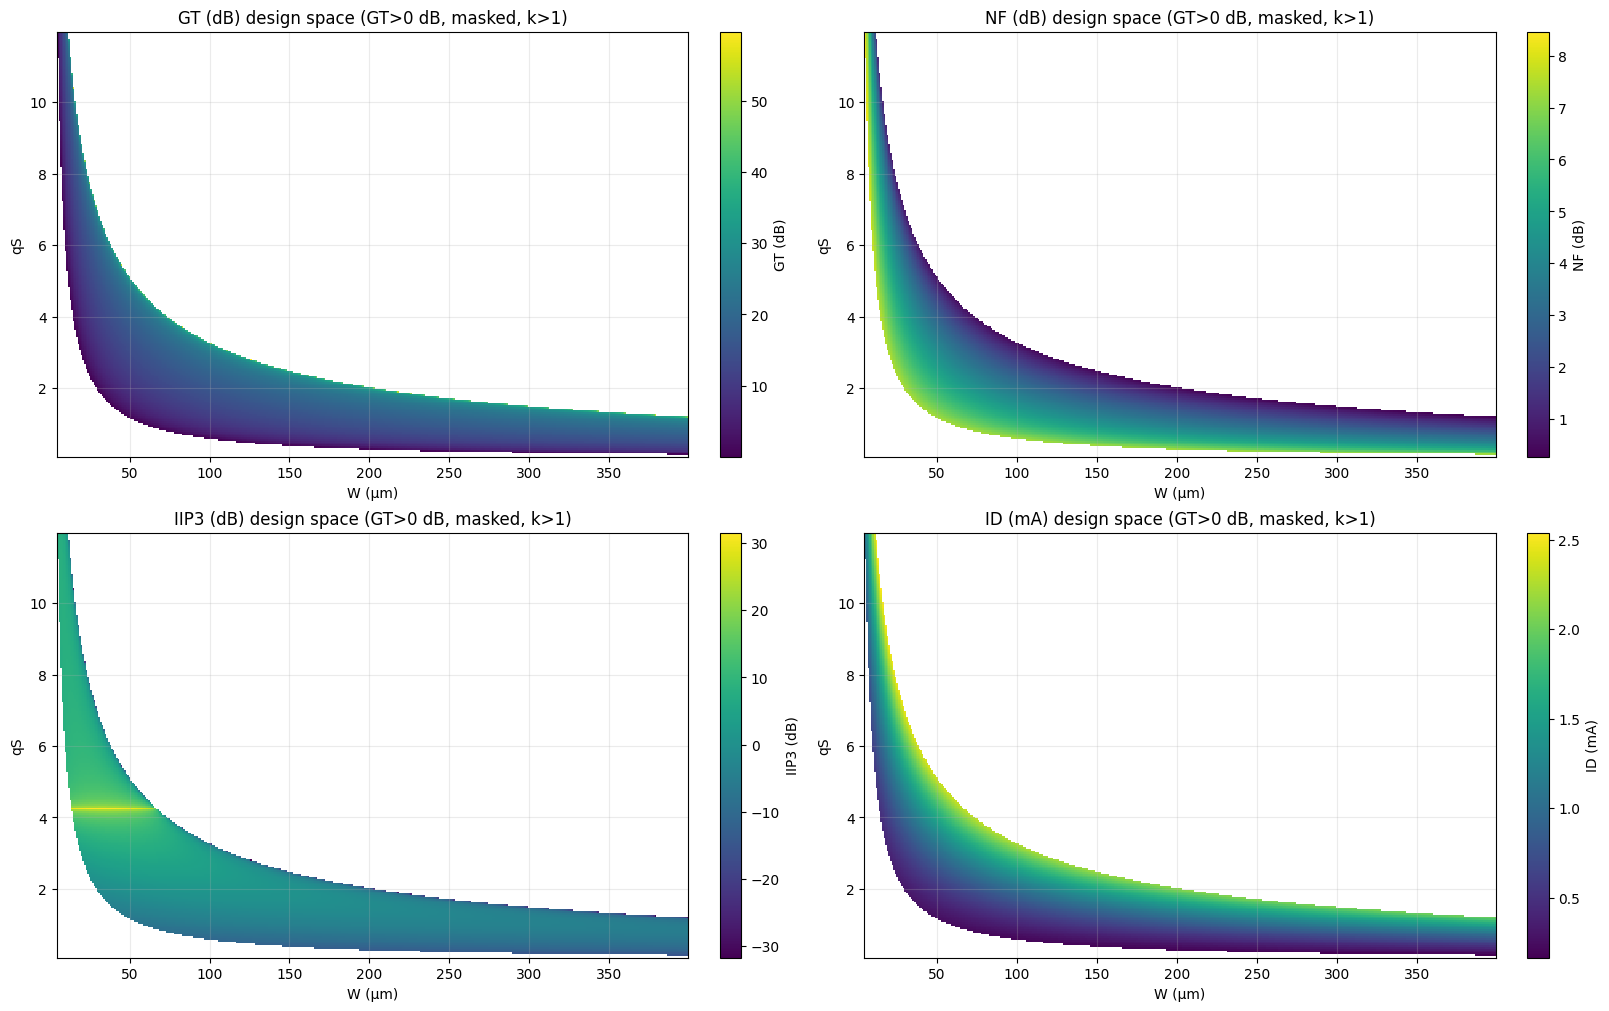


Target: GT = 15
Crossings per W (min/mean/max): 0 0.9873417721518988 1
Coverage: 98.7% of W have a solution (with k>1 + physical mask).


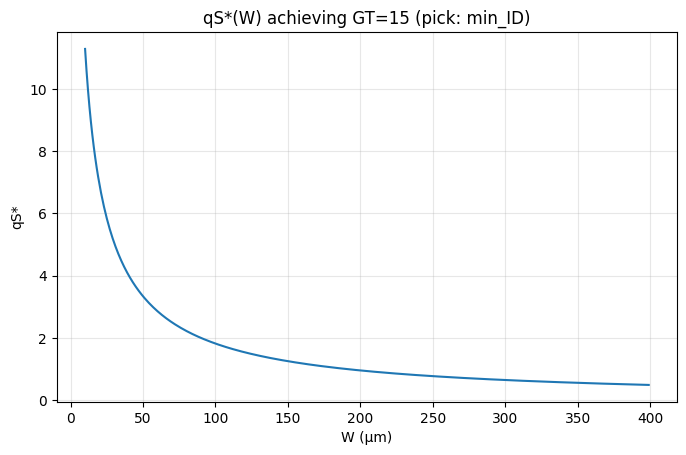

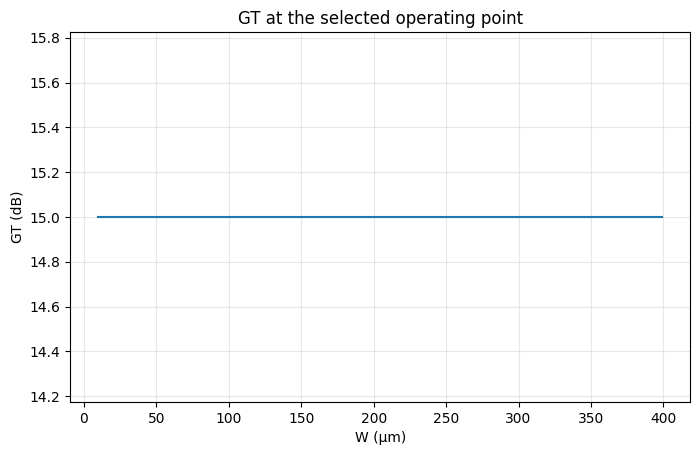

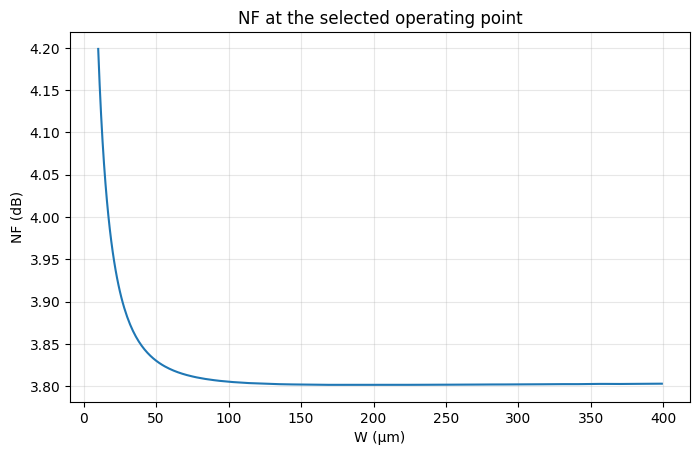

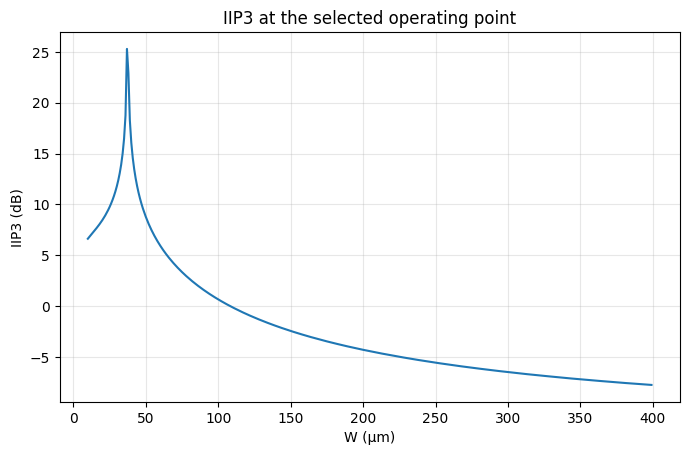

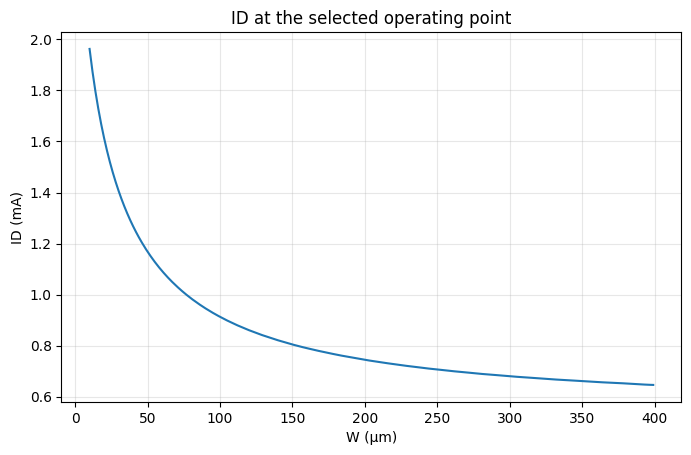


Type a W (in µm) to query along the solved curve: 150

================ Query result (chosen W on solved curve) ================
W                : 150.000 µm
qS*              : 1.2571
ID               : 0.804545 mA
GT               : 15.000 dB
NF               : 3.802 dB
IIP3             : -2.427 dBm
gm               : 1.283297e-02 S
RL               : 1118.645 Ω
RO               : 831.995 Ω
RF               : 551.268 Ω
k = gm*RF         : 7.074
QIN              : 1.539
Gv               : 3.654

--- Input matching ---
RP               : 118.461 Ω
QP               : 1.170
RIN              : 50.000 Ω
CP               : 175.803 fF
Cgs              : 872.267 fF
Lg               : 7.459 nH

--- ACM VG for this qS ---
VD (ACM)          : 0.900 V
VG*               : 0.5188 V
Plot qS(VG) and mark VG*? (y/n): y


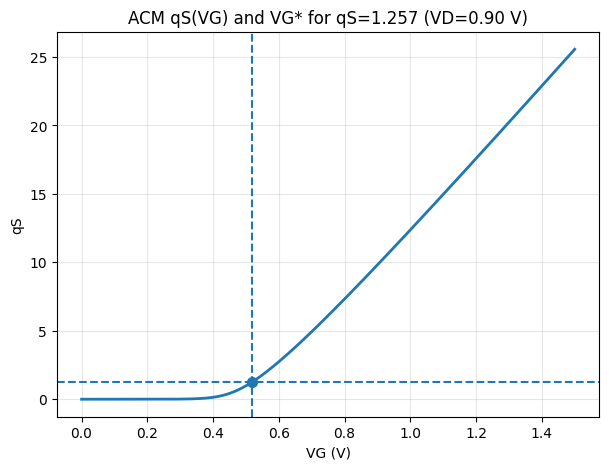

In [ ]:
#@title LNA design space exploration - v11 (full) + ACM VG + input match + extra vars
import numpy as np
import matplotlib.pyplot as plt

# ============================
# Parameters (yours)
# ============================
VT0   = 523e-3
ISL   = 1.31
n     = 1.39
sigma = 24e-3
zeta  = 32e-3

fc   = 6e9
N    = 4
cL   = 80e-15
VDD  = 1.8
Rs   = 50.0
L    = 180e-9
fo   = fc / N
phit = 25.83e-3

# Consistent bias for LNA + ACM
VDS_BIAS = VDD / 2.0
VD_ACM   = VDS_BIAS  # with VS=0

# ============================
# Wide sweep ranges
# ============================
qS_values = np.arange(0.1, 12.0, 0.05)
W_values  = np.arange(5e-6, 400e-6, 1e-6)
W_um      = W_values * 1e6

W_mesh, qS_mesh = np.meshgrid(W_values, qS_values)

# ============================================================
# ACM helper: Algorithm 443 + qS(VG) + invert to VG(qS)
# ============================================================
def algo_443_scalar(Z):
    if not np.isfinite(Z) or Z <= 0:
        return np.nan

    if Z < 0.7385:
        numerator = Z + (4.0/3.0)*Z*Z
        denominator = 1.0 + (7.0/3.0)*Z + (5.0/6.0)*Z*Z
        Wn = numerator / denominator
    else:
        lnZ = np.log(Z)
        numerator = lnZ*lnZ + 2.0*lnZ - 3.0
        denominator = 7.0*lnZ*lnZ + 58.0*lnZ + 127.0
        Wn = lnZ - 24.0*(numerator / denominator)

    Zn = np.log(Z) - Wn - np.log(Wn)
    Term = Zn / (1.0 + Wn)
    numeratorE = 2.0*(1.0 + Wn)*(1.0 + Wn + (2.0/3.0)*Zn) - Zn
    denominatorE = 2.0*(1.0 + Wn)*(1.0 + Wn + (2.0/3.0)*Zn) - 2.0*Zn
    En = Term * (numeratorE / denominatorE)

    return Wn * (1.0 + En)

def qS_from_VG_ACM(VG_vec, VT0, sigma, n, phit, VD, VS=0.0):
    qS_vec = np.zeros_like(VG_vec, dtype=float)
    for i, VG in enumerate(VG_vec):
        VP = (VG - VT0 + sigma*(VD + VS)) / n
        X  = np.exp(((VP - VS)/phit) + 1.0)
        qS_vec[i] = algo_443_scalar(X)
    return qS_vec

def find_VG_for_qS(qS_target, VT0, sigma, n, phit, VD, VS=0.0,
                   VG_min=0.0, VG_max=1.5, VG_step=1e-3):
    VG_vec = np.arange(VG_min, VG_max + 0.5*VG_step, VG_step)
    qS_curve = qS_from_VG_ACM(VG_vec, VT0, sigma, n, phit, VD=VD, VS=VS)

    d = qS_curve - qS_target
    for i in range(len(VG_vec)-1):
        d0, d1 = d[i], d[i+1]
        if not (np.isfinite(d0) and np.isfinite(d1)):
            continue
        if d0 == 0.0:
            return VG_vec[i], qS_curve, VG_vec
        if d0 * d1 > 0:
            continue
        t = (0.0 - d0) / (d1 - d0)
        t = float(np.clip(t, 0.0, 1.0))
        VG_star = VG_vec[i] + t*(VG_vec[i+1] - VG_vec[i])
        return VG_star, qS_curve, VG_vec

    # fallback: closest
    idx = int(np.nanargmin(np.abs(d)))
    return VG_vec[idx], qS_curve, VG_vec

# ============================================================
# Helper: recompute extra LNA variables at one (qS, W)
# ============================================================
def compute_extra_LNA_vars_at_point(qS_val, W_val):
    i_f_pt = (qS_val + 1.0)**2 - 1.0
    ID_pt  = i_f_pt * ISL * W_val  # A

    VDS_pt = VDS_BIAS
    RL_pt  = (VDD - VDS_pt) / ID_pt

    gm_pt = 2.0 * ((ISL * W_val) / (n * phit)) * (qS_val / (1.0 + zeta * (1.0 + qS_val)))

    gmsat3_pt = 16.0 * ((ISL * W_val) / (n * phit)**3) * (qS_val / ((qS_val + 1.0)**3)) * \
               ((2.0 - (2.0 * zeta * qS_val) - (3.0 * zeta * qS_val**2)) / ((zeta * qS_val + 2.0)**4))

    gds_pt = sigma * gm_pt
    rds_pt = 1.0 / gds_pt
    RO_pt  = (RL_pt * rds_pt) / (RL_pt + rds_pt)

    den_pt = (2.0 * np.pi * cL * N * fo - 1.0 / RO_pt)
    RF_pt  = 1.0 / den_pt

    k_pt = gm_pt * RF_pt
    QIN_pt = np.sqrt((RO_pt + RF_pt) / (Rs * (1.0 + gm_pt * RO_pt)))

    Gv_pt  = ((k_pt - 1.0) * RO_pt) / (RO_pt + RF_pt)
    GT_pt  = Gv_pt * QIN_pt
    GT_dB_pt = 20.0 * np.log10(np.abs(GT_pt))

    VIIP3_pt = (2.0 / QIN_pt) * np.sqrt(np.abs((2.0 * gm_pt) / (gmsat3_pt)))
    IIP3_pt = (VIIP3_pt*VIIP3_pt)/(2*50)  # P = Vpeak^2 / 2*R & Vrms = Vpeak/sqrt(2) We are considering a 50 ohm resistance at the input
    IIP3_dBm_pt = 10.0 * np.log10(np.abs(IIP3_pt*1000))

    gamma = 1 + 2*n*zeta*zeta*((qS_val+1)*(qS_val+1)-1)
    frac1_pt = 4.0 * (((RF_pt) / (QIN_pt * QIN_pt)) + Rs)**2
    frac2_pt = (QIN_pt * QIN_pt * gm_pt * Rs) * \
               ((((RF_pt) / (QIN_pt * QIN_pt)) + Rs + ((gm_pt * Rs * RF_pt * RL_pt) / (RF_pt + RL_pt))))**2
    frac3_pt = (1.0 + ((QIN_pt * QIN_pt * gm_pt * Rs * RF_pt) / (RF_pt + QIN_pt * QIN_pt * Rs)))**2

    F_pt = 1.0 + (frac1_pt / frac2_pt) * (gamma + (1.0 / (gm_pt * RL_pt)) + frac3_pt / (gm_pt * RF_pt))
    NF_dB_pt = 10.0 * np.log10(F_pt)

    # Input match (your equations)
    RP_pt  = (RO_pt + RF_pt) / (1.0 + gm_pt * RO_pt)
    QP_pt  = np.sqrt(QIN_pt**2 - 1.0) if QIN_pt >= 1.0 else np.nan
    RIN_pt = RP_pt / (1.0 + QP_pt**2) if np.isfinite(QP_pt) else np.nan
    CP_pt  = (RO_pt**2) * cL * ((gm_pt * RF_pt) - 1.0) / ((RO_pt + RF_pt)**2)

    Cgs_pt = (QP_pt / (RP_pt * 2.0 * np.pi * fo)) - CP_pt if np.isfinite(QP_pt) else np.nan
    Lg_pt  = (1.0 / (2.0 * np.pi * fo)) * (QP_pt**2) / ((1.0 + QP_pt**2) * Cgs_pt * 2.0 * np.pi * fo) \
             if (np.isfinite(QP_pt) and np.isfinite(Cgs_pt) and Cgs_pt > 0) else np.nan

    return {
        "qS": qS_val,
        "W_um": W_val * 1e6,
        "ID_mA": ID_pt * 1e3,
        "RL_ohm": RL_pt,
        "RO_ohm": RO_pt,
        "RF_ohm": RF_pt,
        "gm_S": gm_pt,
        "k": k_pt,
        "QIN": QIN_pt,
        "Gv": Gv_pt,
        "GT_dB": GT_dB_pt,
        "IIP3_dB": IIP3_dBm_pt,
        "NF_dB": NF_dB_pt,
        "RP_ohm": RP_pt,
        "QP": QP_pt,
        "RIN_ohm": RIN_pt,
        "CP_F": CP_pt,
        "Cgs_F": Cgs_pt,
        "Lg_H": Lg_pt,
    }

def print_report(tag, extras, VG_star):
    print(f"\n================ {tag} ================")
    print(f"W                : {extras['W_um']:.3f} µm")
    print(f"qS*              : {extras['qS']:.4f}")
    print(f"ID               : {extras['ID_mA']:.6f} mA")
    print(f"GT               : {extras['GT_dB']:.3f} dB")
    print(f"NF               : {extras['NF_dB']:.3f} dB")
    print(f"IIP3             : {extras['IIP3_dB']:.3f} dBm")
    print(f"gm               : {extras['gm_S']:.6e} S")
    print(f"RL               : {extras['RL_ohm']:.3f} Ω")
    print(f"RO               : {extras['RO_ohm']:.3f} Ω")
    print(f"RF               : {extras['RF_ohm']:.3f} Ω")
    print(f"k = gm*RF         : {extras['k']:.3f}")
    print(f"QIN              : {extras['QIN']:.3f}")
    print(f"Gv               : {extras['Gv']:.3f}")
    print("\n--- Input matching ---")
    print(f"RP               : {extras['RP_ohm']:.3f} Ω")
    print(f"QP               : {extras['QP']:.3f}")
    print(f"RIN              : {extras['RIN_ohm']:.3f} Ω")
    print(f"CP               : {extras['CP_F']*1e15:.3f} fF")
    print(f"Cgs              : {extras['Cgs_F']*1e15:.3f} fF")
    print(f"Lg               : {extras['Lg_H']*1e9:.3f} nH")
    print("\n--- ACM VG for this qS ---")
    print(f"VD (ACM)          : {VD_ACM:.3f} V")
    print(f"VG*               : {VG_star:.4f} V")

# ============================
# Compute design space maps (masked + k>1)
# ============================
i_f = (qS_mesh + 1.0)**2 - 1.0
ID  = i_f * ISL * W_mesh               # A

VDS = VDS_BIAS
RL  = (VDD - VDS) / ID                 # Ohm

gm = 2.0 * ((ISL * W_mesh) / (n * phit)) * (qS_mesh / (1.0 + zeta * (1.0 + qS_mesh)))

gmsat3 = 16.0 * ((ISL * W_mesh) / (n * phit)**3) * (qS_mesh / ((qS_mesh + 1.0)**3)) * \
         ((2.0 - (2.0 * zeta * qS_mesh) - (3.0 * zeta * qS_mesh**2)) / ((zeta * qS_mesh + 2.0)**4))

gds = sigma * gm
rds = 1.0 / gds
RO  = (RL * rds) / (RL + rds)

den = (2.0 * np.pi * cL * N * fo - 1.0 / RO)
RF  = 1.0 / den

# Physical validity
den_eps = 1e-12
valid = np.isfinite(ID) & (ID > 0)
valid &= np.isfinite(gm) & (gm > 0)
valid &= np.isfinite(gmsat3) & (gmsat3 != 0)
valid &= np.isfinite(RL) & (RL > 0)
valid &= np.isfinite(RO) & (RO > 0)
valid &= np.isfinite(den) & (np.abs(den) > den_eps)
valid &= np.isfinite(RF) & (RF > 0)
valid &= (RO + RF) > 0

def mask(x):
    return np.where(valid, x, np.nan)

ID_mA  = mask(ID * 1e3)     # mA
gm_m   = mask(gm)
RO_m   = mask(RO)
RF_m   = mask(RF)
RL_m   = mask(RL)

# k>1
k = gm_m * RF_m
k = np.where(k > 1.0, k, np.nan)

QIN = np.sqrt((RO_m + RF_m) / (Rs * (1.0 + gm_m * RO_m)))
QIN = np.where(np.isfinite(QIN) & (QIN > 0), QIN, np.nan)

Gv    = ((k - 1.0) * RO_m) / (RO_m + RF_m)
GT    = Gv * QIN
GT_dB = mask(20.0 * np.log10(np.abs(GT)))

VIIP3    = (2.0 / QIN) * np.sqrt(np.abs((2.0 * gm_m) / (gmsat3)))
IIP3 = (VIIP3*VIIP3)/(2*50)  # P = Vpeak^2 / 2*R & Vrms = Vpeak/sqrt(2) We are considering a 50 ohm resistance at the input
IIP3_dBm = mask(10.0 * np.log10(np.abs(IIP3*1000)))

gamma = 1 + 2*n*zeta*zeta*((qS_mesh+1)*(qS_mesh+1)-1)
frac1 = 4.0 * (((RF_m) / (QIN * QIN)) + Rs)**2
frac2 = (QIN * QIN * gm_m * Rs) * \
        ((((RF_m) / (QIN * QIN)) + Rs + ((gm_m * Rs * RF_m * RL_m) / (RF_m + RL_m))))**2
frac3 = (1.0 + ((QIN * QIN * gm_m * Rs * RF_m) / (RF_m + QIN * QIN * Rs)))**2

F     = 1.0 + (frac1 / frac2) * (gamma + (1.0 / (gm_m * RL_m)) + frac3 / (gm_m * RF_m))
NF_dB = mask(10.0 * np.log10(F))


# ============================================================
# Colormap-only mask: show only points with GT > 0 dB
# ============================================================
valid_plot = valid & np.isfinite(GT_dB) & (GT_dB > 0.0)

def mask_plot(x):
    return np.where(valid_plot, x, np.nan)

GT_plot   = mask_plot(GT_dB)
NF_plot   = mask_plot(NF_dB)
IIP3_plot = mask_plot(IIP3_dBm)
ID_plot   = mask_plot(ID_mA)



# ============================================================
# FULL COLORMAPS BEFORE TARGET CHOICE
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

def heat(ax, Z, title, cbar_label):
    im = ax.pcolormesh(W_um, qS_values, Z, shading="auto")
    ax.set_xlabel("W (µm)")
    ax.set_ylabel("qS")
    ax.set_title(title)
    cb = fig.colorbar(im, ax=ax)
    cb.set_label(cbar_label)
    ax.grid(True, alpha=0.25)
    return im

heat(axes[0, 0], GT_plot,   "GT (dB) design space (GT>0 dB, masked, k>1)",   "GT (dB)")
heat(axes[0, 1], NF_plot,   "NF (dB) design space (GT>0 dB, masked, k>1)",   "NF (dB)")
heat(axes[1, 0], IIP3_plot, "IIP3 (dB) design space (GT>0 dB, masked, k>1)", "IIP3 (dB)")
heat(axes[1, 1], ID_plot,   "ID (mA) design space (GT>0 dB, masked, k>1)",   "ID (mA)")

plt.show()

# ============================================================
# Solver: target one metric -> find qS*(W) -> read others
# ============================================================
def interp_from_pair(arr_finite, i, t):
    return arr_finite[i] + t * (arr_finite[i+1] - arr_finite[i])

def solve_target_per_W(target_name, target_value, pick="min_ID"):
    if target_name == "GT":
        T = GT_dB
    elif target_name == "NF":
        T = NF_dB
    elif target_name == "IIP3":
        T = IIP3_dB
    elif target_name == "ID":
        T = ID_mA
    else:
        raise ValueError("target_name must be one of: GT, NF, IIP3, ID")

    qS_star   = np.full(len(W_values), np.nan)
    GT_star   = np.full(len(W_values), np.nan)
    NF_star   = np.full(len(W_values), np.nan)
    IIP3_star = np.full(len(W_values), np.nan)
    ID_star   = np.full(len(W_values), np.nan)
    n_cands   = np.zeros(len(W_values), dtype=int)

    for j in range(len(W_values)):
        yT    = T[:, j]
        yGT   = GT_dB[:, j]
        yNF   = NF_dB[:, j]
        yIIP3 = IIP3_dBm[:, j]
        yID   = ID_mA[:, j]

        finite = np.isfinite(yT) & np.isfinite(yGT) & np.isfinite(yNF) & np.isfinite(yIIP3) & np.isfinite(yID)
        if np.sum(finite) < 2:
            continue

        q      = qS_values[finite]
        tvals  = yT[finite]
        gtvals = yGT[finite]
        nfvals = yNF[finite]
        ip3vals= yIIP3[finite]
        idvals = yID[finite]

        d = tvals - target_value
        cands = []
        for i in range(len(q)-1):
            d0, d1 = d[i], d[i+1]

            if d0 == 0.0:
                t = 0.0
            elif d1 == 0.0:
                t = 1.0
            elif d0 * d1 > 0:
                continue
            else:
                t = (0.0 - d0) / (d1 - d0)

            t = float(np.clip(t, 0.0, 1.0))

            qs  = interp_from_pair(q, i, t)
            gt  = interp_from_pair(gtvals, i, t)
            nf  = interp_from_pair(nfvals, i, t)
            ip3 = interp_from_pair(ip3vals, i, t)
            idm = interp_from_pair(idvals, i, t)

            cands.append((qs, gt, nf, ip3, idm))

        n_cands[j] = len(cands)
        if len(cands) == 0:
            continue

        if pick == "min_ID":
            best = min(cands, key=lambda x: x[4])
        elif pick == "min_NF":
            best = min(cands, key=lambda x: x[2])
        elif pick == "max_IIP3":
            best = max(cands, key=lambda x: x[3])
        else:
            best = cands[0]

        qS_star[j], GT_star[j], NF_star[j], IIP3_star[j], ID_star[j] = best

    return qS_star, GT_star, NF_star, IIP3_star, ID_star, n_cands

# ============================================================
# USER CHOICE: select ONE target variable
# ============================================================
target_name  = "GT"       # "GT" | "NF" | "IIP3" | "ID"
target_value =   15     # dB for GT/NF/IIP3, or mA for ID if target_name="ID"
pick_multi   = "min_ID"

qS_star, GT_star, NF_star, IIP3_star, ID_star, n_cands = solve_target_per_W(
    target_name, target_value, pick=pick_multi
)

print(f"\nTarget: {target_name} = {target_value}")
print("Crossings per W (min/mean/max):", np.min(n_cands), np.mean(n_cands), np.max(n_cands))
print(f"Coverage: {100*np.mean(np.isfinite(qS_star)):.1f}% of W have a solution (with k>1 + physical mask).")

# ============================================================
# Plots: resulting operating point and resulting specs
# ============================================================
plt.figure(figsize=(8,4.8))
plt.plot(W_um, qS_star)
plt.xlabel("W (µm)")
plt.ylabel("qS*")
plt.title(f"qS*(W) achieving {target_name}={target_value} (pick: {pick_multi})")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,4.8))
plt.plot(W_um, GT_star)
plt.xlabel("W (µm)")
plt.ylabel("GT (dB)")
plt.title("GT at the selected operating point")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,4.8))
plt.plot(W_um, NF_star)
plt.xlabel("W (µm)")
plt.ylabel("NF (dB)")
plt.title("NF at the selected operating point")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,4.8))
plt.plot(W_um, IIP3_star)
plt.xlabel("W (µm)")
plt.ylabel("IIP3 (dB)")
plt.title("IIP3 at the selected operating point")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(8,4.8))
plt.plot(W_um, ID_star)
plt.xlabel("W (µm)")
plt.ylabel("ID (mA)")
plt.title("ID at the selected operating point")
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# Prompt 1 (UPDATED): user chooses W -> script reads qS*, GT, NF, IIP3, ID
# then prints extra variables + VG (ACM with VD=VDD/2)
# ============================================================
ok_curve = np.isfinite(qS_star) & np.isfinite(GT_star) & np.isfinite(NF_star) & np.isfinite(IIP3_star) & np.isfinite(ID_star)

if not np.any(ok_curve):
    print("\nNo operating-point curve available to query (coverage is zero).")
else:
    try:
        W_query_um = float(input("\nType a W (in µm) to query along the solved curve: "))
        W_query = W_query_um * 1e-6

        # Find closest W index among all W_values (then ensure it's valid on curve)
        j0 = int(np.argmin(np.abs(W_values - W_query)))

        # If j0 is invalid on curve, search nearest valid index
        if not ok_curve[j0]:
            valid_idx = np.where(ok_curve)[0]
            j0 = int(valid_idx[np.argmin(np.abs(W_values[valid_idx] - W_query))])

        qS_sel = float(qS_star[j0])
        W_sel  = float(W_values[j0])

        # Recompute all extra variables at this operating point
        extras = compute_extra_LNA_vars_at_point(qS_sel, W_sel)

        # ACM: find VG that yields this qS (using VD = VDD/2)
        VG_star, qS_curve, VG_vec = find_VG_for_qS(
            qS_target=qS_sel,
            VT0=VT0, sigma=sigma, n=n, phit=phit,
            VD=VD_ACM, VS=0.0,
            VG_min=0.0, VG_max=1.5, VG_step=1e-3
        )

        print_report("Query result (chosen W on solved curve)", extras, VG_star)

        do_plot = input("Plot qS(VG) and mark VG*? (y/n): ").strip().lower()
        if do_plot == "y":
            plt.figure(figsize=(7,5))
            plt.plot(VG_vec, qS_curve, linewidth=2.0)
            plt.axhline(qS_sel, linestyle="--")
            plt.axvline(VG_star, linestyle="--")
            plt.scatter([VG_star], [qS_sel], s=50)
            plt.xlabel("VG (V)")
            plt.ylabel("qS")
            plt.title(f"ACM qS(VG) and VG* for qS={qS_sel:.3f} (VD={VD_ACM:.2f} V)")
            plt.grid(True, alpha=0.3)
            plt.show()

    except Exception as e:
        print("\nInput skipped / invalid. Error:", e)


In [ ]:
# ============================================================
# (NEW) After target: user selects a qS to query operating point
# Prompt #1: closest point on solved curve qS*(W)
# Prompt #2: for fixed qS, choose W that min NF / min ID / max IIP3
# ============================================================

ok_curve = np.isfinite(qS_star) & np.isfinite(GT_star) & np.isfinite(NF_star) & np.isfinite(IIP3_star) & np.isfinite(ID_star)

# ---------- Prompt #1: query along the solved curve ----------
if not np.any(ok_curve):
    print("\nNo operating-point curve available to query (coverage is zero).")
else:
    try:
        qS_query = float(input("\n[Prompt 1] Type a qS to query along the solved curve qS*(W): "))
        # closest point on the curve
        j_best = np.nanargmin(np.abs(qS_star[ok_curve] - qS_query))
        j_idx  = np.where(ok_curve)[0][j_best]

        print("\n--- Closest operating point on the solved curve ---")
        print(f"Requested qS     : {qS_query:.4f}")
        print(f"Found qS*(W)     : {qS_star[j_idx]:.4f}")
        print(f"W               : {W_values[j_idx]*1e6:.3f} µm")
        print(f"GT (dB)          : {GT_star[j_idx]:.3f}")
        print(f"NF (dB)          : {NF_star[j_idx]:.3f}")
        print(f"IIP3 (dB)        : {IIP3_star[j_idx]:.3f}")
        print(f"ID (mA)          : {ID_star[j_idx]:.6f}")

    except Exception as e:
        print("\nPrompt 1 skipped / invalid. Error:", e)

# ---------- Prompt #2: fixed qS, choose best W ----------
try:
    qS_query2 = float(input("\n[Prompt 2] Type a qS to search over ALL W (min NF / min ID / max IIP3): "))

    # choose which metric to optimize
    metric_choice = input("Choose metric to optimize: 'NF' (min), 'ID' (min), or 'IIP3' (max): ").strip().upper()
    if metric_choice not in ["NF", "ID", "IIP3"]:
        raise ValueError("metric_choice must be one of: NF, ID, IIP3")

    # optional minimum gain constraint for this fixed-qS search
    GT_min_query = float(input("Optional constraint: minimum GT in dB (type 0 to disable): "))
    use_GT_min = (GT_min_query > 0)

    # nearest qS row in the grid
    iq = int(np.argmin(np.abs(qS_values - qS_query2)))
    qS_used = qS_values[iq]

    # row vectors across W
    row_GT   = GT_dB[iq, :]
    row_NF   = NF_dB[iq, :]
    row_IIP3 = IIP3_dB[iq, :]
    row_ID   = ID_mA[iq, :]

    ok = np.isfinite(row_GT) & np.isfinite(row_NF) & np.isfinite(row_IIP3) & np.isfinite(row_ID)
    if use_GT_min:
        ok &= (row_GT >= GT_min_query)

    if not np.any(ok):
        print("\nNo valid W found at this qS under the chosen constraint.")
    else:
        if metric_choice == "NF":
            j = int(np.nanargmin(np.where(ok, row_NF, np.nan)))
            tag = "Min NF"
        elif metric_choice == "ID":
            j = int(np.nanargmin(np.where(ok, row_ID, np.nan)))
            tag = "Min ID"
        else:  # IIP3
            j = int(np.nanargmax(np.where(ok, row_IIP3, np.nan)))
            tag = "Max IIP3"

        print("\n--- Best W at fixed qS (search over full W range) ---")
        print(f"Requested qS     : {qS_query2:.4f}")
        print(f"Used grid qS     : {qS_used:.4f}")
        print(f"Objective        : {tag}")
        if use_GT_min:
            print(f"Constraint        : GT >= {GT_min_query:.2f} dB")
        else:
            print("Constraint        : none (besides physical mask + k>1)")

        print(f"W               : {W_values[j]*1e6:.3f} µm")
        print(f"GT (dB)          : {row_GT[j]:.3f}")
        print(f"NF (dB)          : {row_NF[j]:.3f}")
        print(f"IIP3 (dB)        : {row_IIP3[j]:.3f}")
        print(f"ID (mA)          : {row_ID[j]:.6f}")

except Exception as e:
    print("\nPrompt 2 skipped / invalid. Error:", e)



Objective = min_NF, coverage = 98.7% (W columns feasible)


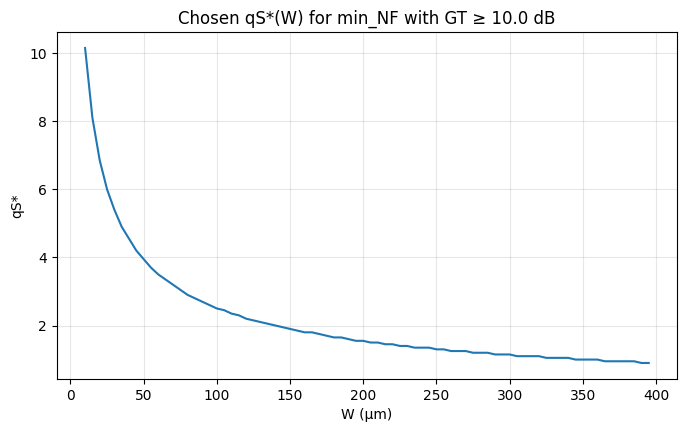

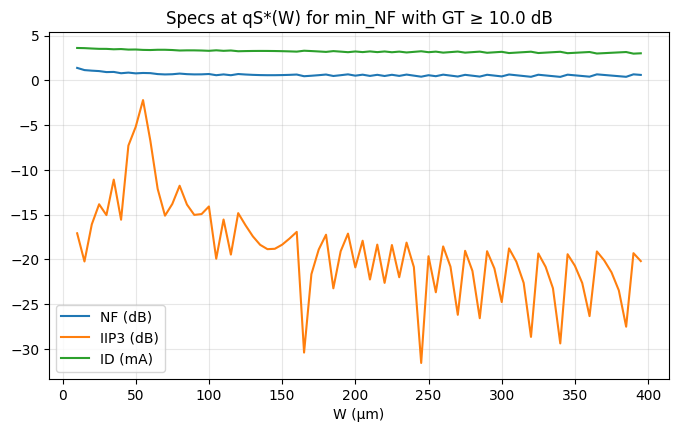


Objective = min_ID, coverage = 98.7% (W columns feasible)


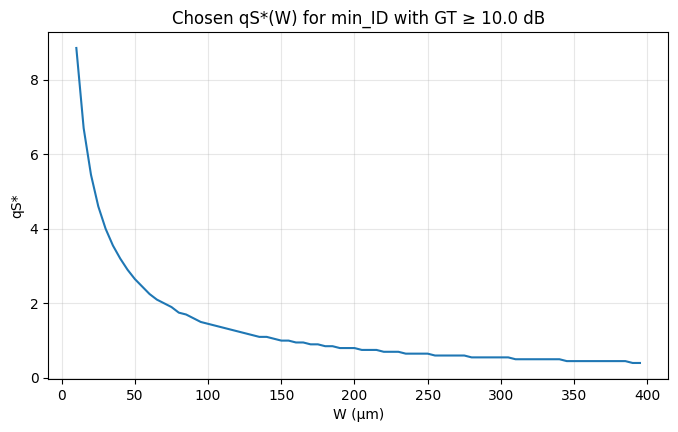

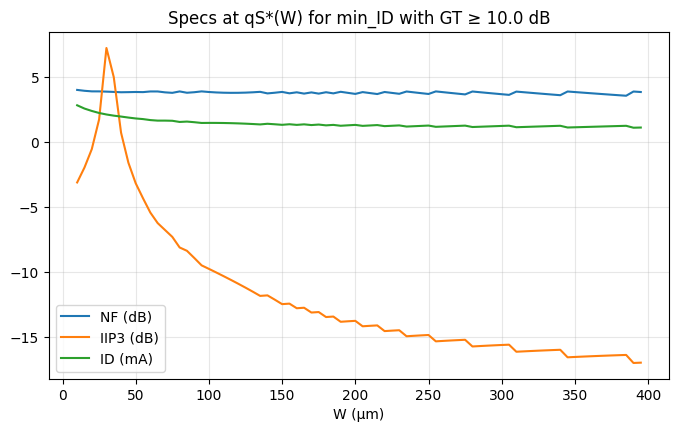


Objective = max_IIP3, coverage = 98.7% (W columns feasible)


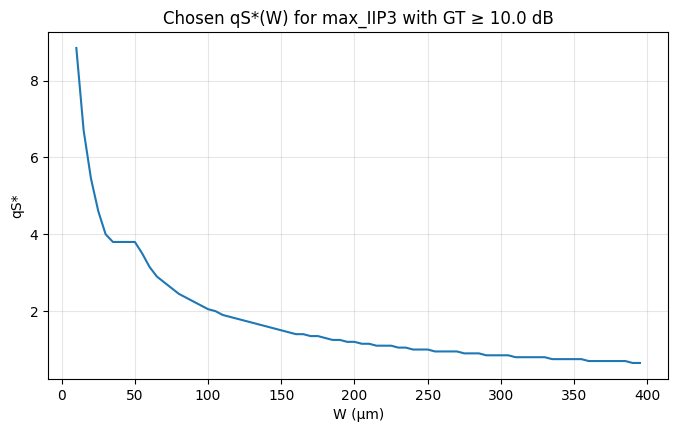

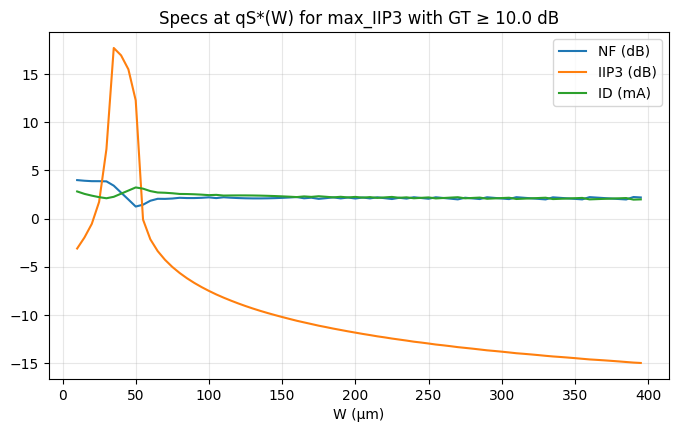

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Constraints (EDIT)
# ----------------------------
GT_min_dB = 10.0        # "real LNA" constraint
use_NF_max   = False; NF_max_dB   = 6.0
use_IIP3_min = False; IIP3_min_dB = -20.0
use_ID_max   = False; ID_max_mA   = 1.0   # mA

def build_feasible_mask():
    m = np.isfinite(GT_dB) & np.isfinite(NF_dB) & np.isfinite(IIP3_dB) & np.isfinite(ID_mA)
    m &= (GT_dB >= GT_min_dB)
    if use_NF_max:
        m &= (NF_dB <= NF_max_dB)
    if use_IIP3_min:
        m &= (IIP3_dB >= IIP3_min_dB)
    if use_ID_max:
        m &= (ID_mA <= ID_max_mA)
    return m

feasible = build_feasible_mask()

# ----------------------------
# Pick best qS for each W
# objective: "min_NF" | "min_ID" | "max_IIP3"
# ----------------------------
def pick_best_qS_per_W(objective="min_NF"):
    qS_star   = np.full(len(W_values), np.nan)
    GT_star   = np.full(len(W_values), np.nan)
    NF_star   = np.full(len(W_values), np.nan)
    IIP3_star = np.full(len(W_values), np.nan)
    ID_star   = np.full(len(W_values), np.nan)

    for j in range(len(W_values)):
        ok = feasible[:, j]
        if not np.any(ok):
            continue

        if objective == "min_NF":
            idx = np.nanargmin(np.where(ok, NF_dB[:, j], np.nan))
        elif objective == "min_ID":
            idx = np.nanargmin(np.where(ok, ID_mA[:, j], np.nan))
        elif objective == "max_IIP3":
            idx = np.nanargmax(np.where(ok, IIP3_dB[:, j], np.nan))
        else:
            raise ValueError("objective must be: min_NF, min_ID, max_IIP3")

        qS_star[j]   = qS_values[idx]
        GT_star[j]   = GT_dB[idx, j]
        NF_star[j]   = NF_dB[idx, j]
        IIP3_star[j] = IIP3_dB[idx, j]
        ID_star[j]   = ID_mA[idx, j]

    return qS_star, GT_star, NF_star, IIP3_star, ID_star

# Example usage:
W_um = W_values * 1e6

for obj in ["min_NF", "min_ID", "max_IIP3"]:
    qS_star, GT_star, NF_star, IIP3_star, ID_star = pick_best_qS_per_W(obj)

    print(f"\nObjective = {obj}, coverage = {100*np.mean(np.isfinite(qS_star)):.1f}% (W columns feasible)")

    plt.figure(figsize=(8,4.5))
    plt.plot(W_um, qS_star)
    plt.xlabel("W (µm)"); plt.ylabel("qS*")
    plt.title(f"Chosen qS*(W) for {obj} with GT ≥ {GT_min_dB} dB")
    plt.grid(True, alpha=0.3); plt.show()

    plt.figure(figsize=(8,4.5))
    plt.plot(W_um, NF_star, label="NF (dB)")
    plt.plot(W_um, IIP3_star, label="IIP3 (dB)")
    plt.plot(W_um, ID_star, label="ID (mA)")
    plt.xlabel("W (µm)")
    plt.title(f"Specs at qS*(W) for {obj} with GT ≥ {GT_min_dB} dB")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


In [ ]:
# Choose a specific qS (nearest grid point)
qS_target = 2.5
iq = int(np.argmin(np.abs(qS_values - qS_target)))
print("Using qS =", qS_values[iq])

# Feasible mask on that row (optional GT constraint)
ok_row = np.isfinite(GT_dB[iq, :]) & np.isfinite(NF_dB[iq, :]) & np.isfinite(IIP3_dB[iq, :]) & np.isfinite(ID_mA[iq, :])
ok_row &= (GT_dB[iq, :] >= GT_min_dB)   # keep this; remove if you want unconstrained

if not np.any(ok_row):
    print("No feasible W for this qS under the constraints.")
else:
    j_nf   = int(np.nanargmin(np.where(ok_row, NF_dB[iq, :],   np.nan)))
    j_id   = int(np.nanargmin(np.where(ok_row, ID_mA[iq, :],   np.nan)))
    j_iip3 = int(np.nanargmax(np.where(ok_row, IIP3_dB[iq, :], np.nan)))

    def report(j, tag):
        print(f"\n{tag}: W = {W_values[j]*1e6:.2f} µm")
        print(f"  GT   = {GT_dB[iq,j]:.2f} dB")
        print(f"  NF   = {NF_dB[iq,j]:.2f} dB")
        print(f"  IIP3 = {IIP3_dB[iq,j]:.2f} dB")
        print(f"  ID   = {ID_mA[iq,j]:.4f} mA")

    report(j_nf,   "Min NF")
    report(j_id,   "Min ID")
    report(j_iip3, "Max IIP3")


Using qS = 2.500000000000001

Min NF: W = 100.00 µm
  GT   = 27.06 dB
  NF   = 0.72 dB
  IIP3 = -14.08 dB
  ID   = 3.3075 mA

Min ID: W = 55.00 µm
  GT   = 10.49 dB
  NF   = 3.74 dB
  IIP3 = -4.05 dB
  ID   = 1.8191 mA

Max IIP3: W = 55.00 µm
  GT   = 10.49 dB
  NF   = 3.74 dB
  IIP3 = -4.05 dB
  ID   = 1.8191 mA


<ipython-input-1-6d3df12771e4>:61: RuntimeWarning: invalid value encountered in sqrt
  QIN = np.sqrt((RO + RF) / (Rs * (1 + gm * RO)))


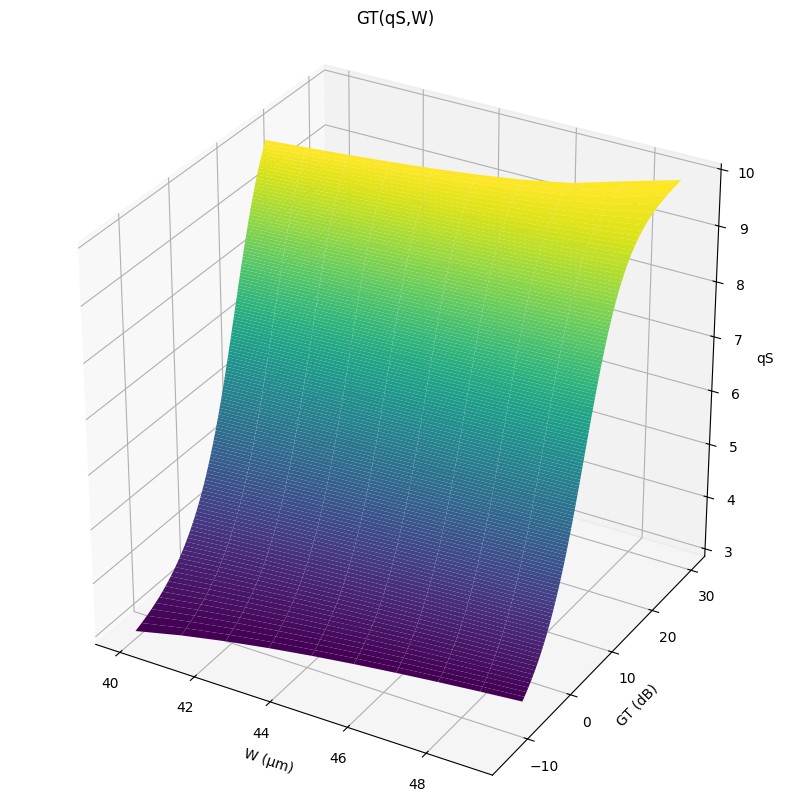

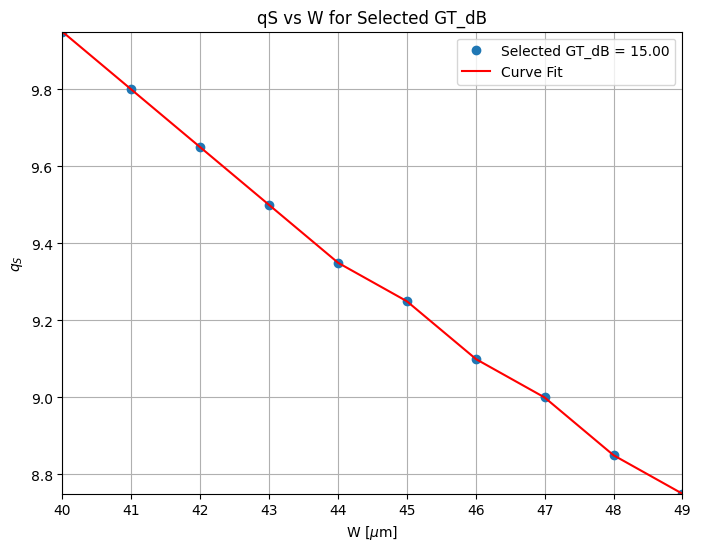

In [ ]:
#@title Choose GT to see the qs(W)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from scipy.interpolate import interp1d


########## Input Variables - LNA ####################
fc = 6e9
N = 4
cL = 200e-15
VDD = 1.5  # core supply voltage of the technology in V
Rs = 50  # ohms <-- Series resistance
L = 0.12e-6  # transistor length
fo = fc / N
phit = 25.8e-3  # Thermal voltage

############## Input arrays ###################
qS_values = np.arange(3, 10, 0.05)  # qS array
W_values = np.arange(40e-6, 50e-6, 1e-6)  # W array in meters

# Model parameters
VT0 = 490e-3  # Threshold voltage
ISL = 1.178  # Specific current normalized by W = 10e-6
n = 1.43  # Slope factor
sigma = 53e-3  # DIBL
zeta = 7e-3  # Saturation velocity parameter


# Calculate i_f from qS
i_f = (qS_values + 1)**2 - 1
i_f = i_f[:, np.newaxis]  # Shape (181, 1)
# Calculate the drain current from if
ID = i_f*ISL*W_values  # ISL * W_values

# Calculate VDSsat based on the inversion level
VDSsat = phit * (np.sqrt(1 + i_f) + 3)

#################### Load resistance ########################
RL = (VDD - VDSsat) / ID

W_mesh, qS_mesh = np.meshgrid(W_values, qS_values)

# Create meshgrid for W and qS for plotting
W_2D, qS_2D = np.meshgrid(W_values * 1e6, qS_values)  # W in micrometers

# Calculate transconductance gm
gm = 2 * ((ISL * W_mesh) / (n * phit)) * (qS_mesh / (1 + zeta * (1 + qS_mesh)))

# Calculate rds and RO
gds = sigma * gm
rds = np.where(gds != 0, 1 / gds, np.nan)  # Avoid division by zero
RO = np.where(rds != np.nan, (RL * rds) / (RL + rds), np.nan)

# Calculate RF
ROmin = 1 / (2 * np.pi * cL * N * fo)
RF = np.where(RO != 0, 1 / (2 * np.pi * cL * N * fo - 1 / RO), np.nan)

# Calculate voltage gain Gv
QIN = np.sqrt((RO + RF) / (Rs * (1 + gm * RO)))
Gv = ((gm * RF - 1) * RO) / (RO + RF)
GT = Gv * QIN

# Avoid log of zero or negative values
GT = np.where(GT > 0, GT, np.nan)
GT_dB = np.where(GT > 0, 20 * np.log10(np.abs(GT)), np.nan)

# Plot the results
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(W_2D, GT_dB, qS_2D, rstride=1, cstride=1, cmap='viridis', edgecolor='none')

# Labels
ax.set_title(f'GT(qS,W)')
ax.set_xlabel('W (μm)')
ax.set_ylabel('GT (dB)')
ax.set_zlabel('qS')
ax.set_box_aspect([1, 1, 1])
plt.show()

# Ask the user to choose a value of GT_dB
selected_GT_dB = 15

# Flatten the arrays and create a DataFrame with matching lengths
W_flat = W_2D.flatten()
qS_flat = qS_2D.flatten()
GT_dB_flat = GT_dB.flatten()

# Create a DataFrame for qS, W, and GT_dB
data = {
    'qS': qS_flat,
    'W (micrometers)': W_flat,
    'GT_dB': GT_dB_flat
}
df = pd.DataFrame(data)

# Print the range of GT_dB values for debugging
#print(f"RL = {RL} Ohms: GT_dB range = [{GT_dB_flat.min()}, {GT_dB_flat.max()}]")

# Validate and find corresponding qS and W
tolerance = 1e-1
if selected_GT_dB < GT_dB_flat.min() or selected_GT_dB > GT_dB_flat.max():
    print(f"GT_dB must be between {GT_dB_flat.min():.4g} and {GT_dB_flat.max():.4g} dB.")
else:
    # Find rows where GT_dB matches the selected value
    matching_rows = df[np.isclose(df['GT_dB'], selected_GT_dB, atol=tolerance)]

    # Compute mean qS for each W value
    if not matching_rows.empty:
        mean_qS = matching_rows.groupby('W (micrometers)')['qS'].mean().reset_index()

        # Interpolation to create a smooth curve
        sorted_data = mean_qS.sort_values('W (micrometers)')
        f = interp1d(sorted_data['W (micrometers)'], sorted_data['qS'], kind='linear', fill_value="extrapolate")
        W_smooth = np.linspace(sorted_data['W (micrometers)'].min(), sorted_data['W (micrometers)'].max(), 500)
        qS_smooth = f(W_smooth)

        plt.figure(figsize=(8, 6))

        plt.plot(sorted_data['W (micrometers)'], sorted_data['qS'], 'o', label=f'Selected GT_dB = {selected_GT_dB:.2f}')
        plt.plot(W_smooth, qS_smooth, '-', color='red', label='Curve Fit')
        plt.xlabel('W [$\mu$m]')
        plt.ylabel('$q_S$')
        plt.title('qS vs W for Selected GT_dB')
        plt.grid(True)
        plt.legend()

        # Safeguard against NaN or Inf values in axis limits
        W_smooth = W_smooth[np.isfinite(W_smooth)]
        qS_smooth = qS_smooth[np.isfinite(qS_smooth)]

        plt.xlim(W_smooth.min(), W_smooth.max())
        plt.ylim(qS_smooth.min(), qS_smooth.max())

        plt.show()
    else:
        print(f"No matching rows found for GT_dB = {selected_GT_dB:.2f} dB.")

<ipython-input-20-26e2ee8766db>:61: RuntimeWarning: invalid value encountered in sqrt
  QIN = np.sqrt((RO + RF) / (Rs * (1 + gm * RO)))


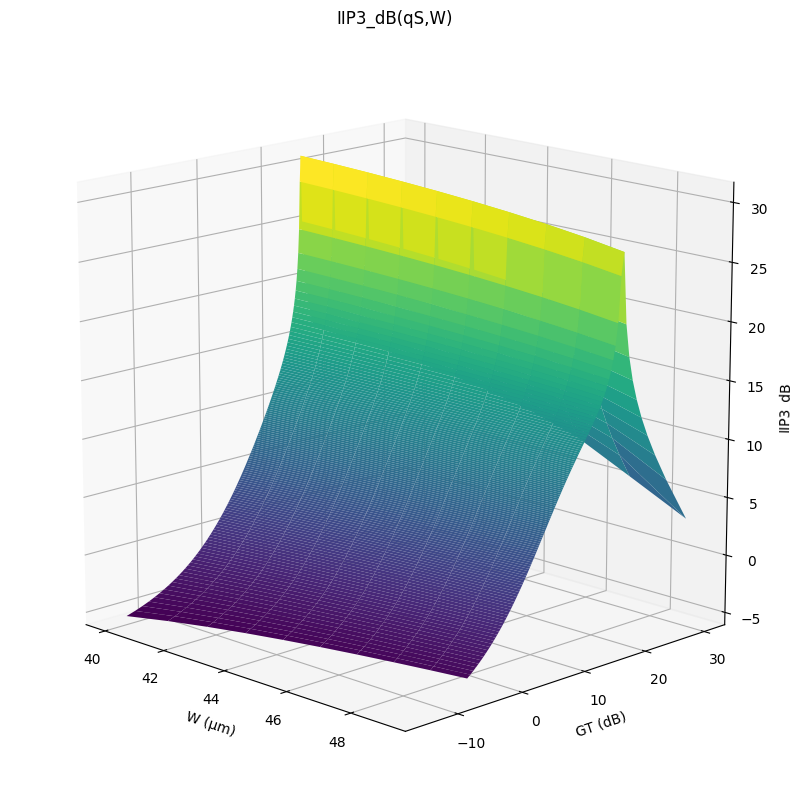

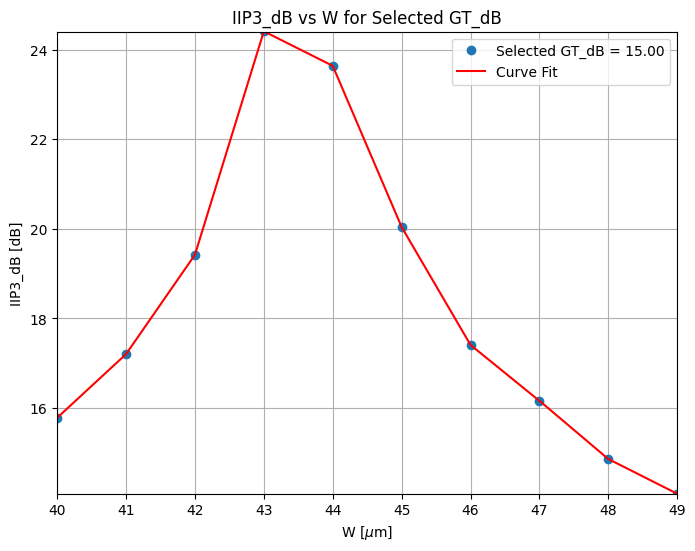

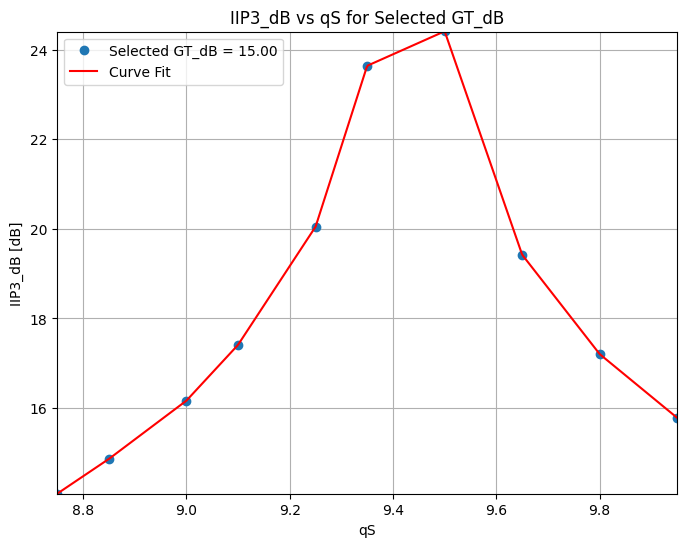

In [ ]:
#@title Choose GT to see the IIP3_dB(W)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from scipy.interpolate import interp1d


########## Input Variables - LNA ####################
fc = 6e9
N = 4
cL = 200e-15
VDD = 1.5  # core supply voltage of the technology in V
Rs = 50  # ohms <-- Series resistance
L = 0.12e-6  # transistor length
fo = fc / N
phit = 25.8e-3  # Thermal voltage

############## Input arrays ###################
qS_values = np.arange(3, 10, 0.05)  # qS array
W_values = np.arange(40e-6, 50e-6, 1e-6)  # W array in meters

# Model parameters
VT0 = 490e-3  # Threshold voltage
ISL = 1.178  # Specific current normalized by W = 10e-6
n = 1.43  # Slope factor
sigma = 53e-3  # DIBL
zeta = 7e-3  # Saturation velocity parameter


# Calculate i_f from qS
i_f = (qS_values + 1)**2 - 1
i_f = i_f[:, np.newaxis]  # Shape (181, 1)
# Calculate the drain current from if
ID = i_f*ISL*W_values  # ISL * W_values

# Calculate VDSsat based on the inversion level
VDSsat = phit * (np.sqrt(1 + i_f) + 3)

#################### Load resistance ########################
RL = (VDD - VDSsat) / ID

W_mesh, qS_mesh = np.meshgrid(W_values, qS_values)

# Create meshgrid for W and qS for plotting
W_2D, qS_2D = np.meshgrid(W_values * 1e6, qS_values)  # W in micrometers

# Calculate transconductance gm and gmsat3
gm = 2 * ((ISL * W_mesh) / (n * phit)) * (qS_mesh / (1 + zeta * (1 + qS_mesh)))
gmsat3 = 16 * ((ISL * W_mesh) / (n * phit)**3) * (qS_mesh / ((qS_mesh + 1)**3))*((2 - (2 * zeta * qS_mesh) - (3 * zeta * qS_mesh**2)) / ((zeta * qS_mesh + 2)**4))
# Calculate rds and RO
gds = sigma * gm
rds = np.where(gds != 0, 1 / gds, np.nan)  # Avoid division by zero
RO = np.where(rds != np.nan, (RL * rds) / (RL + rds), np.nan)

# Calculate RF
ROmin = 1 / (2 * np.pi * cL * N * fo)
RF = np.where(RO != 0, 1 / (2 * np.pi * cL * N * fo - 1 / RO), np.nan)

# Calculate voltage gain Gv
QIN = np.sqrt((RO + RF) / (Rs * (1 + gm * RO)))
Gv = ((gm * RF - 1) * RO) / (RO + RF)
GT = Gv * QIN

# Avoid log of zero or negative values
GT = np.where(GT > 0, GT, np.nan)
GT_dB = np.where(GT > 0, 20 * np.log10(np.abs(GT)), np.nan)

# Calculate IIP3 and IIP3_dB
IIP3 = (2/QIN) * (np.sqrt(abs((2.0 *  gm ) / (gmsat3))))
IIP3_dB = 20 * np.log10(np.abs(IIP3))

# Plot the results
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(W_2D, GT_dB, IIP3_dB, rstride=1, cstride=1, cmap='viridis', edgecolor='none')

# Labels
ax.set_title(f'IIP3_dB(qS,W)')
ax.set_xlabel('W (μm)')
ax.set_ylabel('GT (dB)')
ax.set_zlabel('IIP3_dB')
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=15, azim=315)  # Adjust elevation and azimuth
plt.show()

# Ask the user to choose a value of GT_dB
selected_GT_dB = 15

# Flatten the arrays and create a DataFrame with matching lengths
W_flat = W_2D.flatten()
qS_flat = qS_2D.flatten()
GT_dB_flat = GT_dB.flatten()
IIP3_dB_flat = IIP3_dB.flatten()  # Flatten IIP3_dB for DataFrame

# Create a DataFrame for qS, W, GT_dB, and IIP3_dB
data = {
    'qS': qS_flat,
    'W (micrometers)': W_flat,
    'GT_dB': GT_dB_flat,
    'IIP3_dB': IIP3_dB_flat
}
df = pd.DataFrame(data)

# Print the range of GT_dB values for debugging
#print(f"RL = {RL} Ohms: GT_dB range = [{GT_dB_flat.min()}, {GT_dB_flat.max()}]")

# Validate and find corresponding W and IIP3_dB
tolerance = 1e-1
if selected_GT_dB < GT_dB_flat.min() or selected_GT_dB > GT_dB_flat.max():
    print(f"GT_dB must be between {GT_dB_flat.min():.4g} and {GT_dB_flat.max():.4g} dB.")
else:
    # Find rows where GT_dB matches the selected value
    matching_rows = df[np.isclose(df['GT_dB'], selected_GT_dB, atol=tolerance)]

    # Compute mean IIP3_dB for each W value
    if not matching_rows.empty:
        mean_IIP3_dB = matching_rows.groupby('W (micrometers)')['IIP3_dB'].mean().reset_index()

        # Interpolation to create a smooth curve for IIP3_dB vs W
        sorted_data = mean_IIP3_dB.sort_values('W (micrometers)')
        f = interp1d(sorted_data['W (micrometers)'], sorted_data['IIP3_dB'], kind='linear', fill_value="extrapolate")
        W_smooth = np.linspace(sorted_data['W (micrometers)'].min(), sorted_data['W (micrometers)'].max(), 500)
        IIP3_smooth = f(W_smooth)

        plt.figure(figsize=(8, 6))

        plt.plot(sorted_data['W (micrometers)'], sorted_data['IIP3_dB'], 'o', label=f'Selected GT_dB = {selected_GT_dB:.2f}')
        plt.plot(W_smooth, IIP3_smooth, '-', color='red', label='Curve Fit')
        plt.xlabel('W [$\mu$m]')
        plt.ylabel('IIP3_dB [dB]')
        plt.title('IIP3_dB vs W for Selected GT_dB')
        plt.grid(True)
        plt.legend()

        # Safeguard against NaN or Inf values in axis limits
        W_smooth = W_smooth[np.isfinite(W_smooth)]
        IIP3_smooth = IIP3_smooth[np.isfinite(IIP3_smooth)]

        plt.xlim(W_smooth.min(), W_smooth.max())
        plt.ylim(IIP3_smooth.min(), IIP3_smooth.max())

        plt.show()

        # Plot IIP3_dB vs qS for the selected GT_dB
        mean_IIP3_dB_qS = matching_rows.groupby('qS')['IIP3_dB'].mean().reset_index()

        # Interpolation to create a smooth curve for IIP3_dB vs qS
        sorted_data_qS = mean_IIP3_dB_qS.sort_values('qS')
        f_qS = interp1d(sorted_data_qS['qS'], sorted_data_qS['IIP3_dB'], kind='linear', fill_value="extrapolate")
        qS_smooth = np.linspace(sorted_data_qS['qS'].min(), sorted_data_qS['qS'].max(), 500)
        IIP3_smooth_qS = f_qS(qS_smooth)

        plt.figure(figsize=(8, 6))

        plt.plot(sorted_data_qS['qS'], sorted_data_qS['IIP3_dB'], 'o', label=f'Selected GT_dB = {selected_GT_dB:.2f}')
        plt.plot(qS_smooth, IIP3_smooth_qS, '-', color='red', label='Curve Fit')
        plt.xlabel('qS')
        plt.ylabel('IIP3_dB [dB]')
        plt.title('IIP3_dB vs qS for Selected GT_dB')
        plt.grid(True)
        plt.legend()

        # Safeguard against NaN or Inf values in axis limits
        qS_smooth = qS_smooth[np.isfinite(qS_smooth)]
        IIP3_smooth_qS = IIP3_smooth_qS[np.isfinite(IIP3_smooth_qS)]

        plt.xlim(qS_smooth.min(), qS_smooth.max())
        plt.ylim(IIP3_smooth_qS.min(), IIP3_smooth_qS.max())

        plt.show()
    else:
        print(f"No matching rows found for GT_dB = {selected_GT_dB:.2f} dB.")

<ipython-input-23-b93ec28a9729>:61: RuntimeWarning: invalid value encountered in sqrt
  QIN = np.sqrt((RO + RF) / (Rs * (1 + gm * RO)))


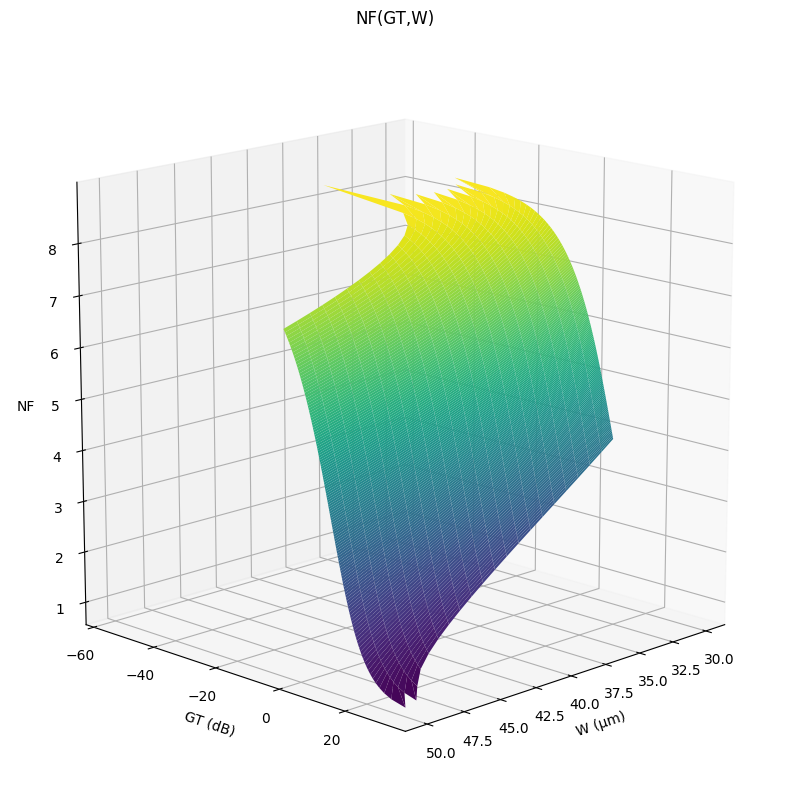

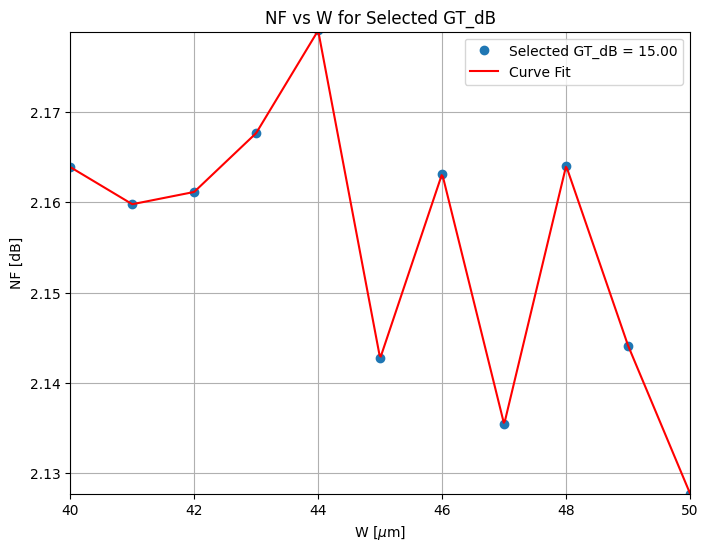

In [ ]:
#@title Choose GT to see the NF(W) and NF(qs)
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
from scipy.interpolate import interp1d


########## Input Variables - LNA ####################
fc = 6e9
N = 4
cL = 200e-15
VDD = 1.5  # core supply voltage of the technology in V
Rs = 50  # ohms <-- Series resistance
L = 0.12e-6  # transistor length
fo = fc / N
phit = 25.8e-3  # Thermal voltage

############## Input arrays ###################
qS_values = np.arange(3, 10, 0.05)  # qS array
W_values = np.arange(30e-6, 50e-6, 1e-6)  # W array in meters

# Model parameters
VT0 = 490e-3  # Threshold voltage
ISL = 1.178  # Specific current normalized by W = 10e-6
n = 1.43  # Slope factor
sigma = 53e-3  # DIBL
zeta = 7e-3  # Saturation velocity parameter


# Calculate i_f from qS
i_f = (qS_values + 1)**2 - 1
i_f = i_f[:, np.newaxis]  # Shape (181, 1)
# Calculate the drain current from if
ID = i_f*ISL*W_values  # ISL * W_values

# Calculate VDSsat based on the inversion level
VDSsat = phit * (np.sqrt(1 + i_f) + 3)

#################### Load resistance ########################
RL = (VDD - VDSsat) / ID

W_mesh, qS_mesh = np.meshgrid(W_values, qS_values)

# Create meshgrid for W and qS for plotting
W_2D, qS_2D = np.meshgrid(W_values * 1e6, qS_values)  # W in micrometers

# Calculate transconductance gm and gmsat3
gm = 2 * ((ISL * W_mesh) / (n * phit)) * (qS_mesh / (1 + zeta * (1 + qS_mesh)))
gmsat3 = 16 * ((ISL * W_mesh) / (n * phit)**3) * (qS_mesh / ((qS_mesh + 1)**3))*((2 - (2 * zeta * qS_mesh) - (3 * zeta * qS_mesh**2)) / ((zeta * qS_mesh + 2)**4))
# Calculate rds and RO
gds = sigma * gm
rds = np.where(gds != 0, 1 / gds, np.nan)  # Avoid division by zero
RO = np.where(rds != np.nan, (RL * rds) / (RL + rds), np.nan)

# Calculate RF
ROmin = 1 / (2 * np.pi * cL * N * fo)
RF = np.where(RO != 0, 1 / (2 * np.pi * cL * N * fo - 1 / RO), np.nan)

# Calculate voltage gain Gv
QIN = np.sqrt((RO + RF) / (Rs * (1 + gm * RO)))
Gv = ((gm * RF - 1) * RO) / (RO + RF)
GT = Gv * QIN

# Avoid log of zero or negative values
GT = np.where(GT > 0, GT, np.nan)
GT_dB = np.where(GT > 0, 20 * np.log10(np.abs(GT)), np.nan)

# Calculate IIP3 and IIP3_dB
IIP3 = (2/QIN) * (np.sqrt(abs((2.0 *  gm ) / (gmsat3))))
IIP3_dB = 20 * np.log10(np.abs(IIP3))

###################### Noise Calculation ##########################
gamma = 0.8
frac1 = 4 * (((RF) / (QIN * QIN)) + Rs) * (((RF) / (QIN * QIN)) + Rs)
frac2 = QIN * QIN * gm * Rs * ((((RF) / (QIN * QIN)) + Rs + ((gm * Rs * RF * RL) / (RF + RL)))) * ((((RF) / (QIN * QIN)) + Rs + ((gm * Rs * RF * RL) / (RF + RL))))
frac3 = (1 + ((QIN * QIN * gm * Rs * RF) / (RF + QIN * QIN * Rs))) * (1 + ((QIN * QIN * gm * Rs * RF) / (RF + QIN * QIN * Rs)))

F = 1 + (frac1 / frac2) * (gamma + (1 / (gm * RL)) + frac3 / (gm * RF))
NF = 10 * np.log10(F)

# Plot the results
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(W_2D, GT_dB, NF, rstride=1, cstride=1, cmap='viridis', edgecolor='none')

# Labels
ax.set_title(f'NF(GT,W)')
ax.set_xlabel('W (μm)')
ax.set_ylabel('GT (dB)')
ax.set_zlabel('NF')
ax.set_box_aspect([1, 1, 1])
ax.view_init(elev=15, azim=45)  # Adjust elevation and azimuth
plt.show()

# Ask the user to choose a value of GT_dB
selected_GT_dB = 15

# Flatten the arrays and create a DataFrame with matching lengths
W_flat = W_2D.flatten()
qS_flat = qS_2D.flatten()
GT_dB_flat = GT_dB.flatten()
NF_flat = NF.flatten()  # Flatten NF for DataFrame

# Create a DataFrame for qS, W, GT_dB, and NF
data = {
    'qS': qS_flat,
    'W (micrometers)': W_flat,
    'GT_dB': GT_dB_flat,
    'NF (dB)': NF_flat
}
df = pd.DataFrame(data)

# Print the range of GT_dB values for debugging
#print(f"RL = {RL} Ohms: GT_dB range = [{GT_dB_flat.min()}, {GT_dB_flat.max()}]")

# Validate and find corresponding W and NF
tolerance = 1e-1
if selected_GT_dB < GT_dB_flat.min() or selected_GT_dB > GT_dB_flat.max():
    print(f"GT_dB must be between {GT_dB_flat.min():.4g} and {GT_dB_flat.max():.4g} dB.")
else:
    # Find rows where GT_dB matches the selected value
    matching_rows = df[np.isclose(df['GT_dB'], selected_GT_dB, atol=tolerance)]

    # Compute mean NF for each W value
    if not matching_rows.empty:
        mean_NF = matching_rows.groupby('W (micrometers)')['NF (dB)'].mean().reset_index()

        # Interpolation to create a smooth curve for NF vs W
        sorted_data = mean_NF.sort_values('W (micrometers)')
        f = interp1d(sorted_data['W (micrometers)'], sorted_data['NF (dB)'], kind='linear', fill_value="extrapolate")
        W_smooth = np.linspace(sorted_data['W (micrometers)'].min(), sorted_data['W (micrometers)'].max(), 500)
        NF_smooth = f(W_smooth)

        plt.figure(figsize=(8, 6))

        plt.plot(sorted_data['W (micrometers)'], sorted_data['NF (dB)'], 'o', label=f'Selected GT_dB = {selected_GT_dB:.2f}')
        plt.plot(W_smooth, NF_smooth, '-', color='red', label='Curve Fit')
        plt.xlabel('W [$\mu$m]')
        plt.ylabel('NF [dB]')
        plt.title('NF vs W for Selected GT_dB')
        plt.grid(True)
        plt.legend()

        # Safeguard against NaN or Inf values in axis limits
        W_smooth = W_smooth[np.isfinite(W_smooth)]
        NF_smooth = NF_smooth[np.isfinite(NF_smooth)]

        plt.xlim(W_smooth.min(), W_smooth.max())
        plt.ylim(NF_smooth.min(), NF_smooth.max())

        plt.show()
    else:
        print(f"No matching rows found for GT_dB = {selected_GT_dB:.2f} dB.")

In [ ]:
#@title calculates GT_dB, IIP3 and NF with a chosen qS and W

import numpy as np

# Constants

W = float(input("Enter the Width in meters: "))
qS = float(input("Enter the value of qs: "))


# Calculate i_f from qS
i_f = (qS + 1)**2 - 1
# Calculate the drain current from if
ID = i_f*ISL*W  # ISL * W_values

# Calculate VDSsat based on the inversion level
VDSsat = phit * (np.sqrt(1 + i_f) + 3)
VDS = VDD / 2.0
#################### Load resistance ########################
RL = (VDD - VDS) / ID

# Calculate gm
gm = 2 * ((ISL * W) / (n * phit)) * (qS / (1 + zeta * (1 + qS)))

# Calculate gds and rds
gds = sigma * gm
rds = 1 / gds

# Calculate RO
RO = (RL * rds) / (RL + rds)

# Calculate RF
fo = fc / N
RF = 1 / (2 * np.pi * cL * N * fo - 1 / RO)

# Calculate QIN
QIN = np.sqrt((RO + RF) / (Rs * (1 + gm * RO)))

# Calculate Gv
Gv = ((gm * RF - 1) * RO) / (RO + RF)

# Calculate GT
GT = Gv * QIN
GT_dB = 20 * np.log10(np.abs(GT))

# Calculate IIP3
gmsat3 = 16 * ((ISL * W) / (n * phit)**3) * (qS / ((qS + 1)**3)) * ((2 - (2 * zeta * qS) - (3 * zeta * qS**2)) / ((zeta * qS + 2)**4))
IIP3 = (2 / QIN) * (np.sqrt(np.abs((2.0 * gm) / (gmsat3))))
IIP3_dB = 20 * np.log10(np.abs(IIP3))

# Calculate NF
gamma = 0.8
frac1 = 4 * (((RF) / (QIN * QIN)) + Rs)**2
frac2 = QIN**2 * gm * Rs * (((RF) / (QIN * QIN)) + Rs + (gm * Rs * RF * RL) / (RF + RL))**2
frac3 = (1 + (QIN**2 * gm * Rs * RF) / (RF + QIN**2 * Rs))**2
F = 1 + (frac1 / frac2) * (gamma + (1 / (gm * RL)) + frac3 / (gm * RF))
NF = 10 * np.log10(F)

#Calculate VG

VG = VT0+ n*phit*(qS - 1 +np.log(qS))

i_f = (qS +1)**2 -1
IDC = i_f*ISL*W

# input match
RP  = (RO+RF)/(1+gm*RO)
QP = np.sqrt((QIN**2) - 1)
RIN = RP/(1+QP**2)
CP = (RO**2)*cL*((gm*RF)-1)/((RO+RF)**2)
#RP = Rs*(1+QP**2)
#RIN = (RO + RF) / ((1 + gm * RO) * (1 + QP))
Cgs = (QP / (RP * 2 * np.pi * fo)) - CP
Lg = (1 / (2 * np.pi * fo)) * (QP**2) / ((1 + QP**2) * Cgs * 2 * np.pi * fo)
# Output results
print("\n" + "="*50)
print(f"RL: {RL} ohms")
print(f"RF: {RF} ohms")
print("\n" + "="*50)
print(f"RO: {RO} ohms")
print("\n" + "="*50)
print(f"GT_dB: {GT_dB} dB")
print(f"IIP3_dB: {IIP3_dB} dB")
print(f"NF: {NF} dB")
print("\n" + "="*50)
print(f"VG: {VG} V")
print(f"VDSsat: {VDSsat} V")
print("\n" + "="*50)
print(f"Ibias: {IDC*1e3} mA")
print("\n" + "="*50)

print("\n" + "="*50)
print(f"QIN = {QIN:.3f}:")
print(f"RIN = {RIN:.3f} ohms")
print("\n" + "="*50)
print(f"QP = {QP:.3f}")
print(f"RP = {RP:.3f} ohms")
print("\n" + "="*50)
print(f"Cgs = {Cgs:.3e} F")
print(f"Lg = {Lg:.3e} H")
print("="*50)


KeyboardInterrupt: Interrupted by user